# Предсказание оттока клиентов телеком-компании

## Описание задачи

https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

Цель проекта — построить модель бинарной классификации, предсказывающую отток клиентов телеком-компании.

Целевая переменная — `Churn`:
- `No` — клиент остался;
- `Yes` — клиент покинул компанию.

В рамках проекта будут проведены:
- исследовательский анализ данных;
- предобработка и feature engineering;
- обучение классических ML-моделей;
- обучение нейронной сети MLP;
- сравнение качества моделей;
- анализ факторов, связанных с оттоком клиентов.


## Импорт библиотек

Все используемые библиотеки импортируются в одном месте перед началом работы с данными.


In [202]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostClassifier, Pool

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## Загрузка и первичный анализ данных

### Загрузка датасета


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Структура и типы данных


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


В датасете присутствуют числовые и категориальные признаки.

К числовым признакам относятся, в частности:
- `tenure` — количество месяцев, в течение которых клиент пользуется услугами компании;
- `MonthlyCharges` — ежемесячная плата;
- `TotalCharges` — общая сумма платежей клиента.

Большая часть остальных признаков является категориальной и описывает демографические характеристики клиента, подключённые услуги, тип контракта и способ оплаты.

На данном этапе видно, что `TotalCharges` имеет тип `object`, хотя по смыслу должен быть числовым. Этот признак необходимо исследовать отдельно.


### Проверка и обработка пропусков


In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Стандартная проверка не выявила пропущенных значений. Однако признак `TotalCharges` имеет тип `object`, хотя по смыслу является числовым.

Дополнительная проверка показала наличие строк, содержащих только пробелы. Такие значения не распознаются `pandas` как `NaN`, поэтому требуется отдельная обработка.


In [ ]:
df["TotalCharges"].value_counts(dropna=False).head(), (df["TotalCharges"].str.strip() == "").sum()

(TotalCharges
          11
 20.2     11
 19.75     9
 20.05     8
 19.9      8
 Name: count, dtype: int64,
 11)

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"].isna().sum()

11

In [ ]:
df.loc[
    df["TotalCharges"].isna(),
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [ ]:
df.loc[df["TotalCharges"].isna(), "tenure"].unique()

array([0], dtype=int64)

Все 11 клиентов с отсутствующим `TotalCharges` имеют `tenure = 0`.

Это новые клиенты, которые ещё не совершили ни одного полного ежемесячного платежа. Поэтому отсутствие `TotalCharges` в данном случае не является случайным пропуском.

С содержательной точки зрения для таких клиентов значение общей суммы платежей можно принять равным 0.


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

### Анализ категориальных значений


In [ ]:
for col in df.columns:
    if df[col].nunique() <= 10:
        print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


## Исследовательский анализ данных (EDA)

### Распределение целевой переменной


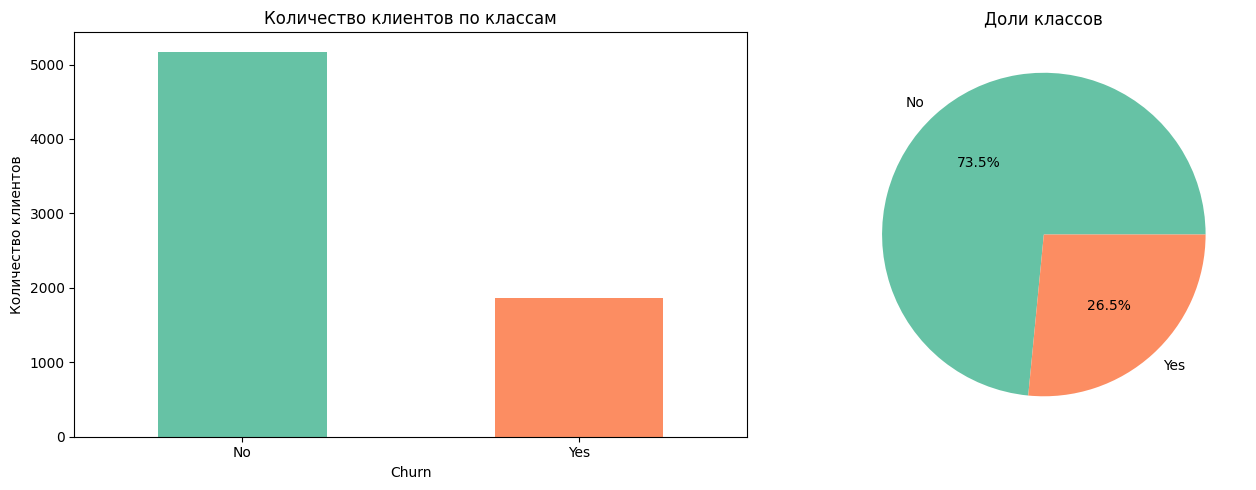

In [ ]:
target_col = "Churn"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(
    ax=axes[0],
    color=sns.color_palette("Set2")
)

axes[0].set_title("Количество клиентов по классам")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Количество клиентов")
axes[0].tick_params(axis="x", rotation=0)

df[target_col].value_counts(normalize=True).plot.pie(
    ax=axes[1],
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2")
)

axes[1].set_ylabel("")
axes[1].set_title("Доли классов")

plt.tight_layout()
plt.show()

В выборке наблюдается умеренный дисбаланс классов: примерно 26.5% клиентов относятся к классу оттока, а 73.5% — к классу без оттока.

Поэтому при оценке моделей нельзя ориентироваться только на Accuracy. Модель, всегда предсказывающая отсутствие оттока, уже получила бы Accuracy около 73.5%.

В дальнейшем дополнительно будут использоваться Recall, Precision, F1-score, ROC-AUC и матрица ошибок.


### Анализ числовых признаков


#### Распределения числовых признаков


Рассмотрим распределения числовых признаков:
- `tenure` — длительность обслуживания клиента в месяцах;
- `MonthlyCharges` — ежемесячная стоимость услуг;
- `TotalCharges` — общая сумма платежей клиента.

Сначала изучим их основные статистические характеристики и распределения.


In [ ]:
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numeric_cols].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


По описательной статистике видно, что числовые признаки имеют разные масштабы и характер распределения.

- `tenure` принимает значения от 0 до 72 месяцев, медиана составляет 29 месяцев. Это означает, что в выборке есть как совсем новые клиенты, так и пользователи с длительной историей обслуживания.
- `MonthlyCharges` изменяется от 18.25 до 118.75, при этом среднее значение составляет 64.76, а медиана — 70.35.
- `TotalCharges` имеет значительно более широкий диапазон: от 0 до 8684.80. Среднее значение равно 2279.73, а медиана — 1394.55, что указывает на заметную правостороннюю асимметрию распределения.

Разница в масштабах числовых признаков будет важна на этапе обучения моделей, чувствительных к масштабу признаков, например логистической регрессии и MLP.


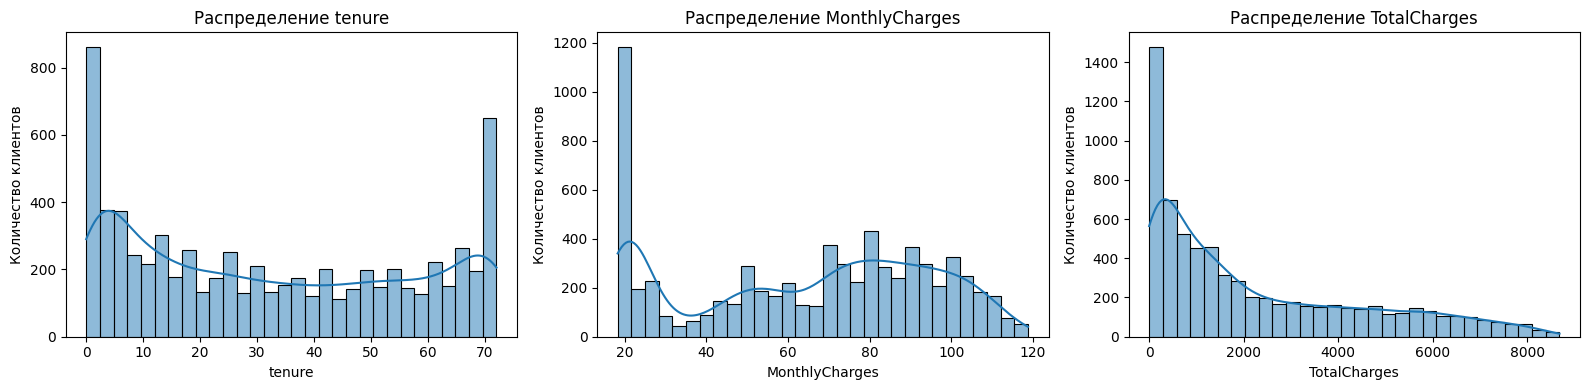

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Распределение {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Количество клиентов")

plt.tight_layout()
plt.show()

Распределения числовых признаков заметно различаются.

- `tenure` имеет выраженные пики около 0 и 72 месяцев. Это означает, что в выборке много как совсем новых клиентов, так и клиентов с максимально долгим сроком обслуживания.
- `MonthlyCharges` имеет неоднородное распределение с несколькими локальными максимумами. Это может быть связано с различными тарифами и комбинациями подключённых услуг.
- `TotalCharges` имеет сильную правостороннюю асимметрию: большинство клиентов имеют относительно небольшую общую сумму платежей, а небольшая часть клиентов — очень высокие значения.

Такая форма распределения `TotalCharges` ожидаема, поскольку этот признак напрямую зависит от срока обслуживания клиента и ежемесячной стоимости услуг.


#### Числовые признаки и отток


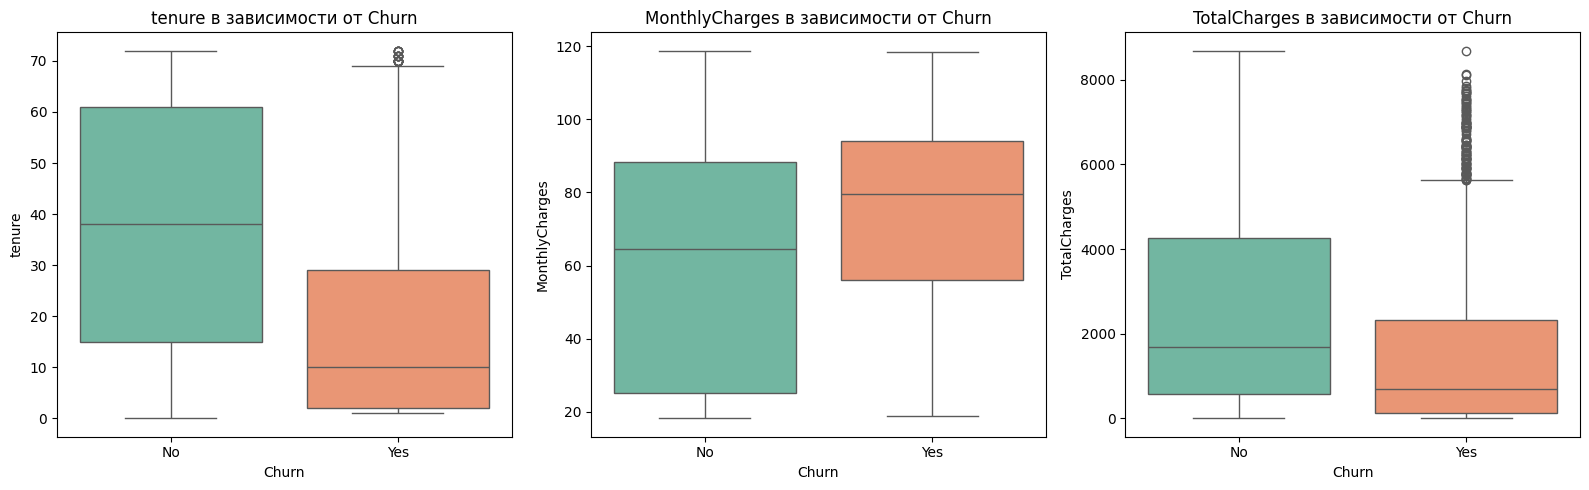

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x="Churn",
        y=col,
        hue="Churn",
        legend=False,
        ax=axes[i],
        palette="Set2"
    )

    axes[i].set_title(f"{col} в зависимости от Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("Churn")[numeric_cols].agg(
    ["mean", "median"]
).round(2)

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

По числовым признакам между ушедшими и оставшимися клиентами наблюдаются заметные различия.

- `tenure` у клиентов с оттоком существенно ниже: среднее значение составляет около 18 месяцев против 38 месяцев у оставшихся клиентов, а медиана — 10 против 38 месяцев. Это указывает на то, что отток особенно характерен для клиентов с небольшой длительностью обслуживания.
- `MonthlyCharges` у ушедших клиентов, наоборот, выше: среднее значение составляет около 74.4 против 61.3, а медиана — 79.65 против 64.43. Более высокая ежемесячная стоимость может быть связана с повышенной вероятностью оттока.
- `TotalCharges` у клиентов с оттоком ниже, несмотря на более высокий `MonthlyCharges`. Это объясняется значительно меньшим `tenure`: ушедшие клиенты в среднем пользуются услугами компании меньше времени и поэтому успевают накопить меньшую общую сумму платежей.

Таким образом, наиболее выраженные различия наблюдаются по `tenure` и `MonthlyCharges`. Эти признаки потенциально могут быть важными предикторами оттока.


#### Проверка выбросов

Для выявления потенциальных выбросов рассмотрим boxplot числовых признаков без разделения по целевой переменной.


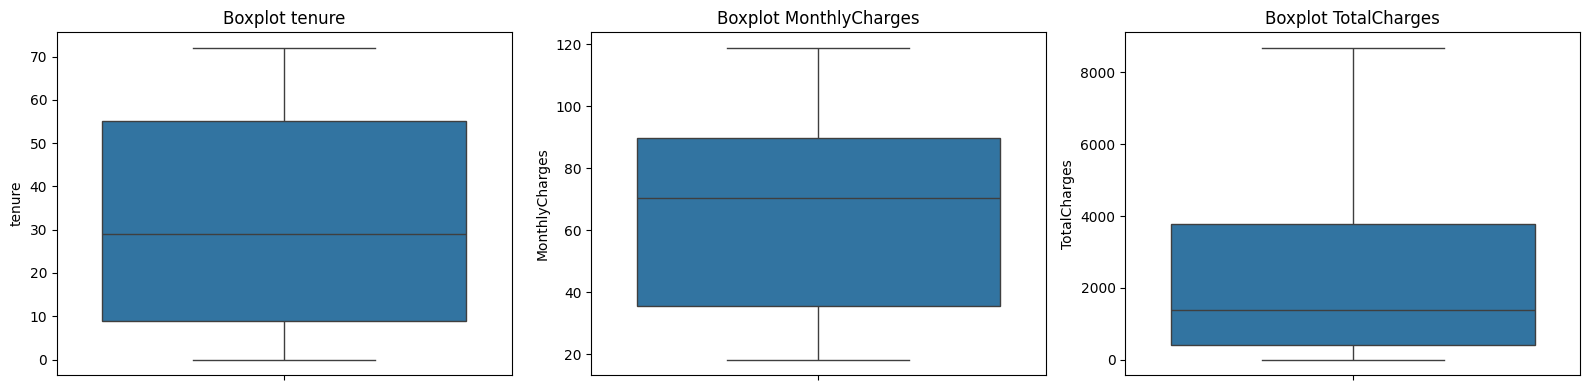

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

По boxplot числовых признаков явных выбросов не обнаружено


#### Корреляционный анализ


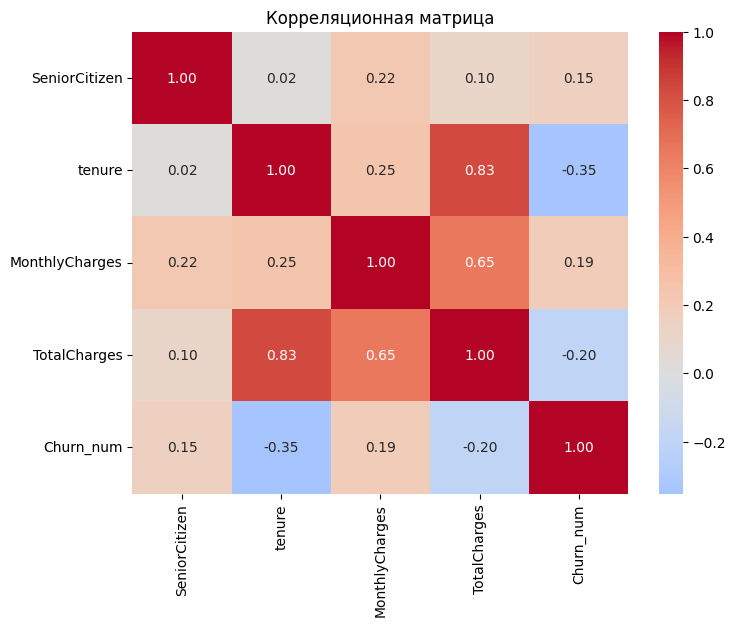

In [ ]:
df["Churn_num"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

corr_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_num"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Корреляционная матрица")
plt.show()

Корреляционный анализ показывает несколько важных зависимостей:

- `tenure` имеет наиболее заметную связь с целевой переменной: коэффициент корреляции с `Churn` составляет `-0.35`. Это согласуется с предыдущим анализом: клиенты с большим сроком обслуживания реже уходят.
- `MonthlyCharges` имеет слабую положительную корреляцию с оттоком (`0.19`), то есть более высокая ежемесячная стоимость может быть связана с повышенной вероятностью ухода.
- `TotalCharges` имеет слабую отрицательную корреляцию с оттоком (`-0.20`), однако этот признак сильно зависит от `tenure`.
- Между `tenure` и `TotalCharges` наблюдается высокая положительная корреляция (`0.83`), что естественно: чем дольше клиент пользуется услугами компании, тем больше его суммарные платежи.
- Также заметна связь между `MonthlyCharges` и `TotalCharges` (`0.65`).

Таким образом, среди числовых признаков наиболее выраженная линейная связь с оттоком наблюдается у `tenure`. При этом высокая корреляция между `tenure` и `TotalCharges` указывает на частичное дублирование информации в этих признаках.


### Анализ оттока в зависимости от типа контракта

Рассмотрим, как доля оттока различается между клиентами с разными типами контрактов.


,clients,churn_rate
Contract,,
Month-to-month,3875,0.427097
One year,1473,0.112695
Two year,1695,0.028319


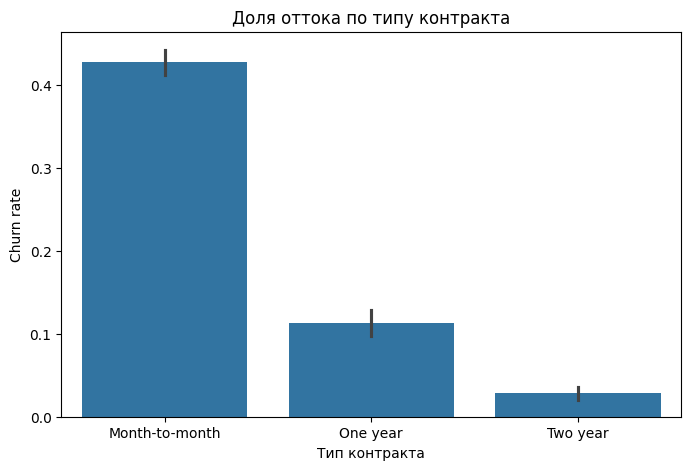

In [ ]:
contract_stats = (
    df.groupby("Contract")
      .agg(
          clients=("Churn_num", "size"),
          churn_rate=("Churn_num", "mean")
      )
      .sort_values("churn_rate", ascending=False)
)

display(contract_stats)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Contract",
    y="Churn_num"
)

plt.title("Доля оттока по типу контракта")
plt.xlabel("Тип контракта")
plt.ylabel("Churn rate")
plt.show()

Тип контракта существенно связан с вероятностью оттока клиентов.

- Среди клиентов с помесячным контрактом (`Month-to-month`) доля оттока составляет около 42.7%.
- Для клиентов с контрактом на один год (`One year`) churn rate снижается до 11.3%.
- Для двухлетних контрактов (`Two year`) доля оттока составляет всего около 2.8%.

Таким образом, чем дольше срок контракта, тем ниже вероятность оттока. Наиболее уязвимой группой являются клиенты с помесячной оплатой, поэтому тип контракта, вероятно, будет одним из наиболее информативных категориальных признаков для модели.


### Анализ оттока в зависимости от типа интернет-сервиса

Рассмотрим, различается ли доля оттока между клиентами с разными типами интернет-подключения.


,clients,churn_rate
InternetService,,
Fiber optic,3096,0.419
DSL,2421,0.190
No,1526,0.074


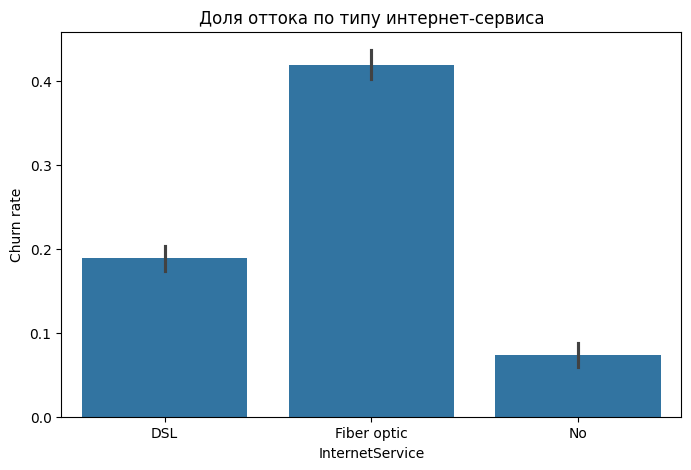

In [ ]:
internet_stats = (
    df.groupby("InternetService")
      .agg(
          clients=("Churn_num", "size"),
          churn_rate=("Churn_num", "mean")
      )
      .sort_values("churn_rate", ascending=False)
)

display(internet_stats.round(3))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="InternetService",
    y="Churn_num"
)

plt.title("Доля оттока по типу интернет-сервиса")
plt.xlabel("InternetService")
plt.ylabel("Churn rate")
plt.show()

Тип интернет-сервиса существенно связан с оттоком клиентов.

- Среди пользователей `Fiber optic` доля оттока составляет около 41.9%.
- Для клиентов с `DSL` churn rate заметно ниже — около 19.0%.
- Минимальная доля оттока наблюдается у клиентов без интернет-сервиса — около 7.4%.

Таким образом, наиболее высокий риск оттока наблюдается у пользователей оптоволоконного интернета. Это может быть связано с более высокой стоимостью услуги, особенностями тарифа или качеством обслуживания, однако по одному этому графику нельзя сделать вывод о причинности.


### Анализ оттока в зависимости от способа оплаты

Рассмотрим, как доля оттока различается между клиентами с разными способами оплаты.


,clients,churn_rate
PaymentMethod,,
Electronic check,2365,0.453
Mailed check,1612,0.191
Bank transfer (automatic),1544,0.167
Credit card (automatic),1522,0.152


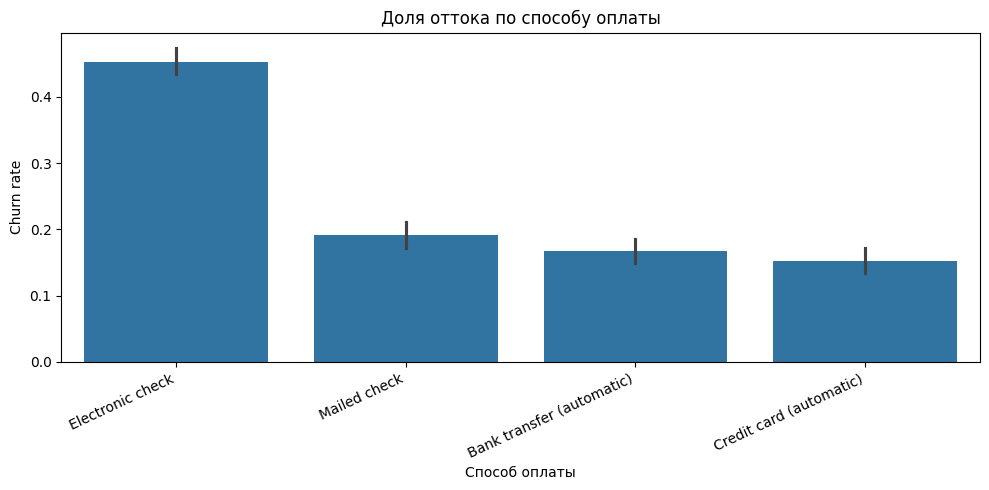

In [ ]:
payment_stats = (
    df.groupby("PaymentMethod")
      .agg(
          clients=("Churn_num", "size"),
          churn_rate=("Churn_num", "mean")
      )
      .sort_values("churn_rate", ascending=False)
)

display(payment_stats.round(3))

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="PaymentMethod",
    y="Churn_num"
)

plt.title("Доля оттока по способу оплаты")
plt.xlabel("Способ оплаты")
plt.ylabel("Churn rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Способ оплаты заметно связан с оттоком клиентов.

- Наибольшая доля оттока наблюдается среди клиентов, использующих `Electronic check` — около 45.3%.
- Для `Mailed check` churn rate составляет около 19.1%.
- Среди клиентов с автоматическими способами оплаты доля оттока ещё ниже: около 16.7% для банковского перевода и 15.2% для кредитной карты.

Таким образом, клиенты, использующие электронный чек, значительно чаще уходят из компании. Автоматические способы оплаты, напротив, связаны с более низким уровнем оттока.


### Анализ оттока в зависимости от дополнительных интернет-услуг

Рассмотрим, как наличие дополнительных услуг связано с долей оттока клиентов.


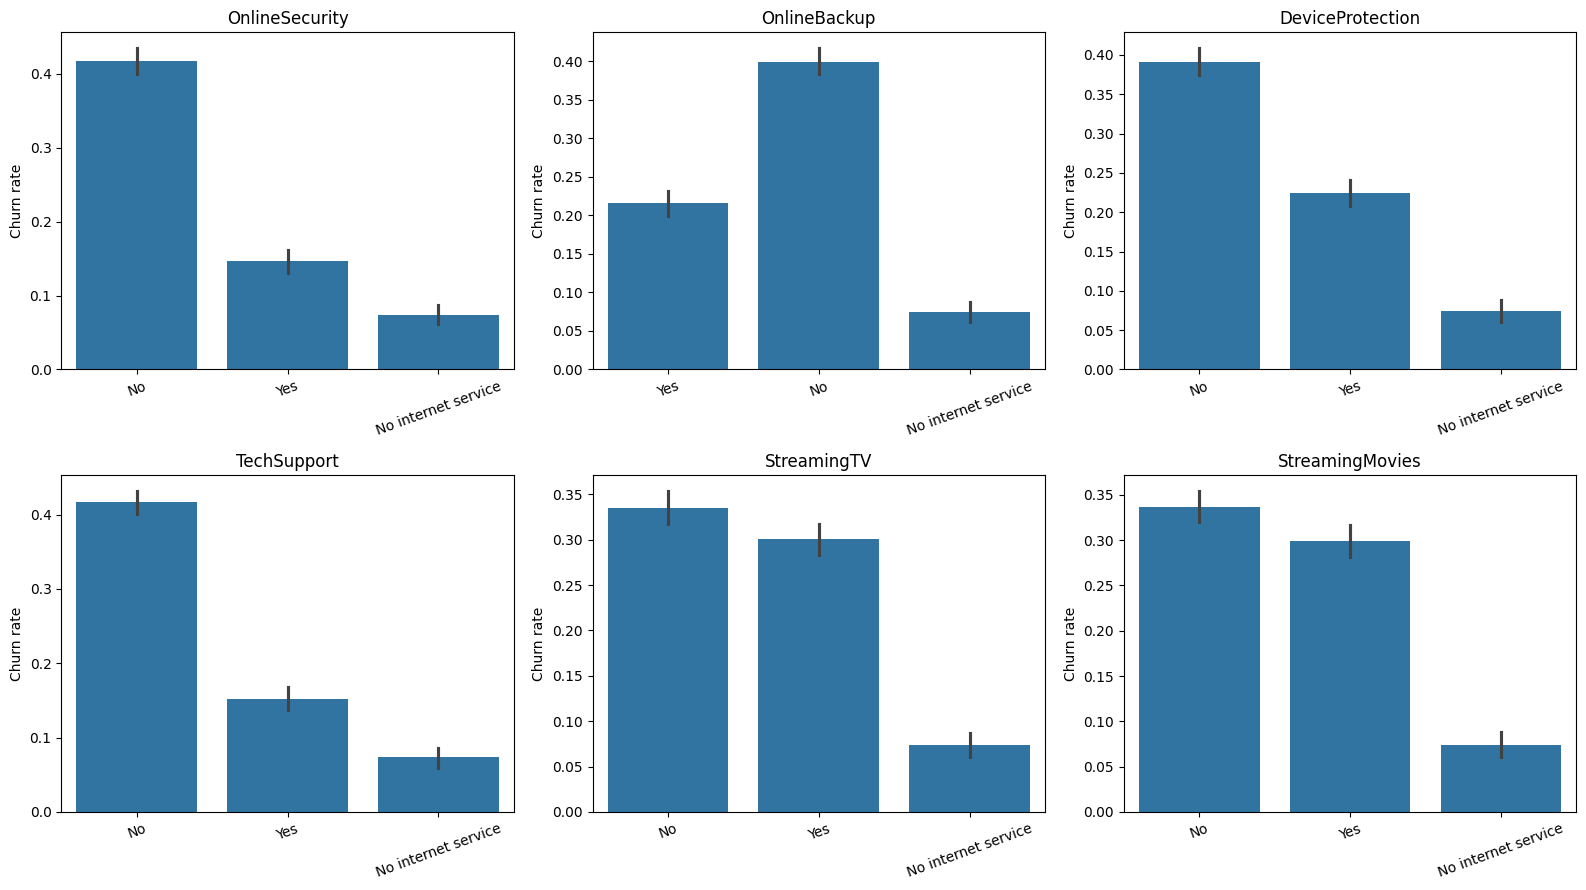

In [ ]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for col, ax in zip(service_cols, axes):
    sns.barplot(
        data=df,
        x=col,
        y="Churn_num",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Дополнительные интернет-услуги по-разному связаны с оттоком клиентов.

Наиболее заметные различия наблюдаются для `OnlineSecurity`, `OnlineBackup`, `DeviceProtection` и `TechSupport`:

- клиенты без этих услуг имеют существенно более высокий churn rate;
- при наличии услуги доля оттока заметно ниже;
- особенно выражена разница для `OnlineSecurity` и `TechSupport`.

Для `StreamingTV` и `StreamingMovies` различия между категориями `Yes` и `No` значительно меньше, поэтому эти признаки, вероятно, слабее связаны с оттоком.

Категорию `No internet service` следует интерпретировать отдельно. Она означает не отсутствие конкретной дополнительной услуги, а отсутствие интернет-сервиса в целом. Поэтому низкий churn rate этой группы нельзя напрямую сравнивать с категориями `Yes` и `No` как с обычными значениями одного признака.

В целом наличие сервисов безопасности и технической поддержки выглядит более связанным с удержанием клиента, чем наличие стриминговых услуг.


### Анализ демографических характеристик клиентов

Рассмотрим связь оттока с полом клиента, возрастной группой, наличием партнёра и иждивенцев.


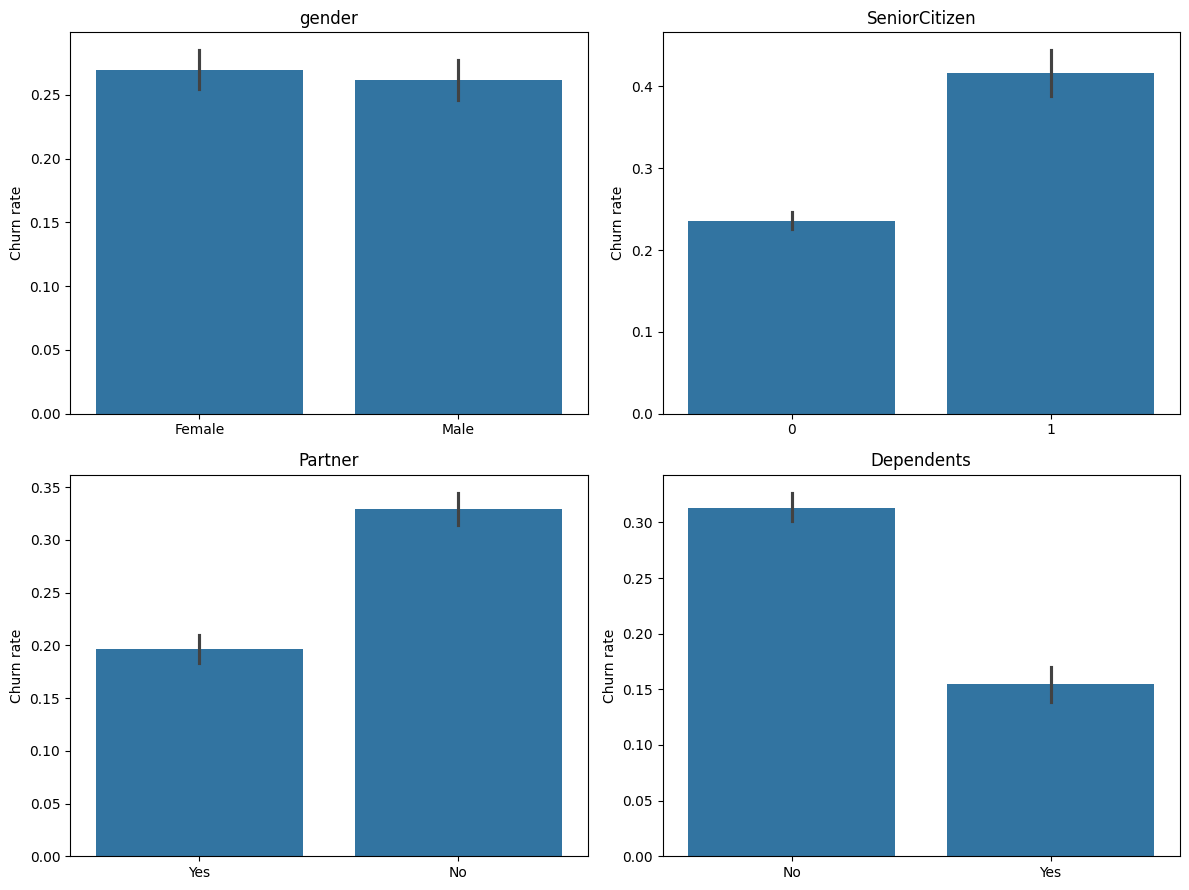

In [ ]:
demo_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for col, ax in zip(demo_cols, axes):
    sns.barplot(
        data=df,
        x=col,
        y="Churn_num",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate")

plt.tight_layout()
plt.show()

Демографические характеристики связаны с оттоком неодинаково.

- `gender` практически не влияет на churn rate: доля оттока у мужчин и женщин почти одинакова.
- У клиентов старшей возрастной группы (`SeniorCitizen = 1`) доля оттока существенно выше — около 42% против примерно 24% у остальных клиентов.
- Клиенты без партнёра уходят чаще: churn rate составляет около 33% против примерно 20% у клиентов с партнёром.
- Аналогичная зависимость наблюдается для `Dependents`: клиенты без иждивенцев имеют заметно более высокий churn rate — около 31% против примерно 16% у клиентов с иждивенцами.

Таким образом, `SeniorCitizen`, `Partner` и `Dependents` могут содержать полезную информацию для прогнозирования оттока, тогда как `gender` по отдельности выглядит малоинформативным признаком.


### Анализ оттока в зависимости от длительности обслуживания

Для более наглядного анализа разделим клиентов на группы по продолжительности обслуживания и сравним долю оттока между ними.


,clients,churn_rate
tenure_group,,
0–6,1481,0.529
7–12,705,0.359
13–24,1024,0.287
25–48,1594,0.204
49–72,2239,0.095


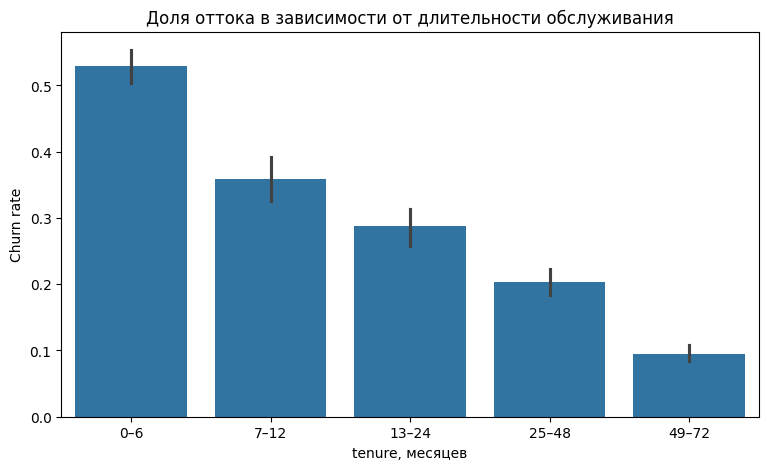

In [ ]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0–6",
        "7–12",
        "13–24",
        "25–48",
        "49–72"
    ]
)

tenure_stats = (
    df.groupby("tenure_group", observed=False)
      .agg(
          clients=("Churn_num", "size"),
          churn_rate=("Churn_num", "mean")
      )
)

display(tenure_stats.round(3))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="tenure_group",
    y="Churn_num"
)

plt.title("Доля оттока в зависимости от длительности обслуживания")
plt.xlabel("tenure, месяцев")
plt.ylabel("Churn rate")
plt.show()

Наиболее высокий риск оттока наблюдается в первые месяцы после подключения. Чем дольше клиент остаётся с компанией, тем ниже вероятность его ухода.


### Совместный анализ MonthlyCharges, типа контракта и оттока

Ранее было показано, что ушедшие клиенты в среднем имеют более высокий `MonthlyCharges`, а тип контракта сильно связан с вероятностью оттока.

Рассмотрим эти признаки совместно, чтобы понять, сохраняется ли различие в ежемесячной стоимости внутри отдельных типов контрактов.


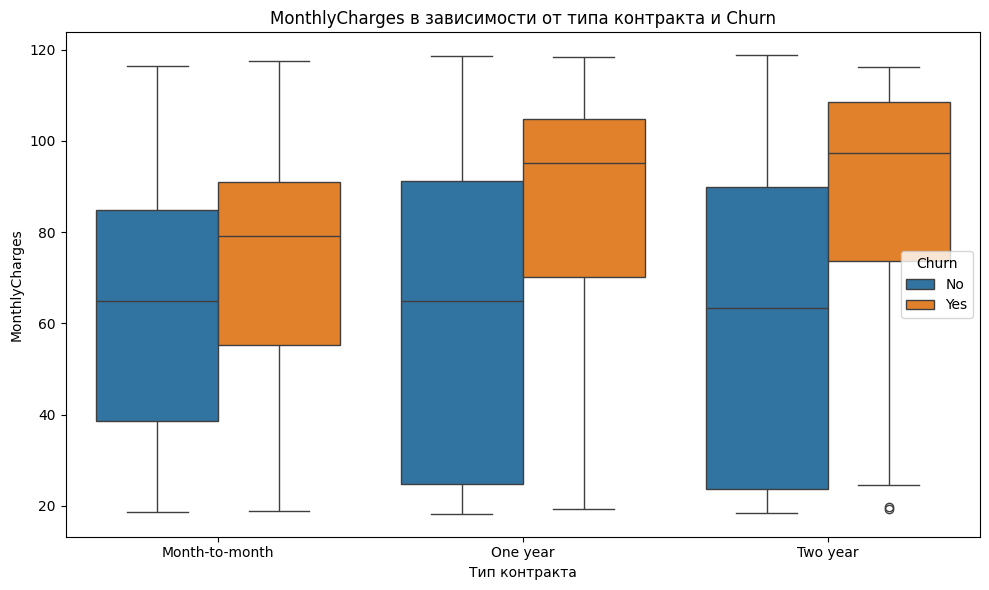

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Contract",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("MonthlyCharges в зависимости от типа контракта и Churn")
plt.xlabel("Тип контракта")
plt.ylabel("MonthlyCharges")
plt.tight_layout()
plt.show()

Внутри каждого типа контракта ушедшие клиенты в среднем имеют более высокий `MonthlyCharges`, чем оставшиеся.

- Для клиентов с помесячным контрактом медиана ежемесячных платежей у ушедших заметно выше.
- Аналогичная картина наблюдается для контрактов на один и два года.
- При этом наиболее высокие значения `MonthlyCharges` среди ушедших клиентов наблюдаются в группах с долгосрочными контрактами.

Следовательно, повышенная ежемесячная стоимость связана с оттоком не только из-за различий в типе контракта. Связь между `MonthlyCharges` и `Churn` сохраняется и внутри отдельных категорий `Contract`.

При этом данный анализ показывает ассоциацию, а не причинную связь: по графику нельзя утверждать, что именно высокая стоимость является причиной ухода клиента.


### Выводы по EDA

В ходе исследовательского анализа данных были выявлены следующие закономерности:

- целевая переменная `Churn` несбалансирована: доля ушедших клиентов составляет около 26.5%, поэтому при оценке моделей необходимо использовать не только Accuracy, но и Recall, Precision, F1-score и ROC-AUC;
- среди числовых признаков наиболее заметная связь с оттоком наблюдается у `tenure`: клиенты с меньшей длительностью обслуживания уходят значительно чаще;
- `MonthlyCharges` у ушедших клиентов в среднем выше, чем у оставшихся;
- `TotalCharges` сильно связан с `tenure`, что объясняет высокую корреляцию между этими признаками;
- явных выбросов в числовых признаках не обнаружено;
- тип контракта сильно связан с оттоком: клиенты с `Month-to-month` контрактом уходят значительно чаще, чем клиенты с годовыми и двухгодичными контрактами;
- наиболее высокий churn rate среди типов интернет-сервиса наблюдается у клиентов с `Fiber optic`;
- клиенты, использующие `Electronic check`, имеют заметно более высокий уровень оттока по сравнению с другими способами оплаты;
- наличие `OnlineSecurity` и `TechSupport` связано с существенно более низкой долей оттока;
- среди демографических признаков наиболее заметные различия наблюдаются для `SeniorCitizen`, `Partner` и `Dependents`, тогда как `gender` практически не связан с оттоком;
- наиболее высокий риск оттока наблюдается в первые месяцы обслуживания клиента, после чего churn rate постепенно снижается.

Полученные результаты показывают, что наибольший интерес для дальнейшего моделирования представляют признаки, связанные с длительностью обслуживания, типом контракта, стоимостью услуг, способом оплаты и набором подключённых сервисов.


## Предобработка данных и Feature Engineering

Перед обучением моделей необходимо удалить технические признаки, использовавшиеся только для идентификации клиентов и проведения EDA, а также создать новые признаки на основе выявленных закономерностей.


### Удаление технических признаков


In [ ]:
df = df.drop(
    columns=[
        "customerID",
        "Churn_num",
        "tenure_group"
    ]
)

`customerID` является уникальным идентификатором клиента и не несёт информации, полезной для прогнозирования оттока.

`Churn_num` и `tenure_group` были созданы только для проведения исследовательского анализа и не будут использоваться в исходном виде при обучении моделей.


### Создание новых признаков

На основе результатов EDA создадим дополнительные признаки:

1. `NumServices` — количество подключённых дополнительных услуг. Предполагается, что клиенты, использующие больше сервисов компании, могут быть сильнее связаны с продуктом и реже уходить.

2. `IsNewCustomer` — индикатор клиента со сроком обслуживания не более 6 месяцев. В ходе EDA было обнаружено, что именно в первые 6 месяцев наблюдается максимальная доля оттока.

3. `AutoPayment` — индикатор использования автоматического способа оплаты. Анализ показал, что клиенты с автоматическими платежами имеют значительно меньший churn rate.


In [ ]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["NumServices"] = (
    df[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

df["IsNewCustomer"] = (
    df["tenure"] <= 6
).astype(int)

df["AutoPayment"] = (
    df["PaymentMethod"]
    .str.contains("automatic", case=False)
    .astype(int)
)

In [ ]:
df[
    [
        "NumServices",
        "IsNewCustomer",
        "AutoPayment"
    ]
].describe().round(2)

,NumServices,IsNewCustomer,AutoPayment
count,7043.00,7043.00,7043.00
mean,2.04,0.21,0.44
std,1.85,0.41,0.50
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,2.00,0.00,0.00
75%,3.00,0.00,1.00
max,6.00,1.00,1.00


Созданные признаки имеют корректные диапазоны значений:

- `NumServices` принимает значения от 0 до 8 и отражает количество подключённых услуг;
- `IsNewCustomer` является бинарным признаком, при этом около 21% клиентов относятся к новым;
- `AutoPayment` также является бинарным признаком, автоматическую оплату используют около 44% клиентов.

Перед использованием новых признаков в моделях проверим, действительно ли они связаны с целевой переменной.


In [ ]:
feature_engineering_stats = pd.DataFrame({
    "IsNewCustomer": df.groupby("IsNewCustomer")["Churn"].apply(
        lambda x: (x == "Yes").mean()
    ),
    "AutoPayment": df.groupby("AutoPayment")["Churn"].apply(
        lambda x: (x == "Yes").mean()
    )
})

feature_engineering_stats.round(3)

,IsNewCustomer,AutoPayment
0,0.195,0.347
1,0.529,0.160


Созданные бинарные признаки показывают заметную связь с оттоком.

- Для новых клиентов (`IsNewCustomer = 1`) churn rate составляет около 52.9%, тогда как среди остальных клиентов — около 19.5%. Это подтверждает вывод EDA о высоком риске оттока в первые месяцы обслуживания.
- Среди клиентов с автоматическим способом оплаты (`AutoPayment = 1`) доля оттока составляет около 16.0%, тогда как среди остальных — около 34.7%.

Таким образом, оба признака содержат дополнительную информацию, связанную с вероятностью оттока, и будут сохранены для дальнейшего моделирования.


,clients,churn_rate
NumServices,,
0,2219,0.214
1,966,0.458
2,1033,0.358
3,1118,0.274
4,852,0.223
5,571,0.124
6,284,0.053


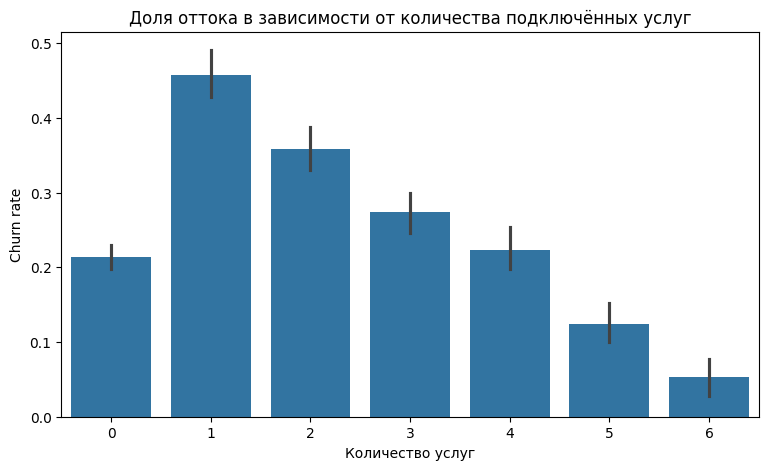

In [ ]:
services_stats = (
    df.assign(Churn_num=(df["Churn"] == "Yes").astype(int))
      .groupby("NumServices")
      .agg(
          clients=("Churn_num", "size"),
          churn_rate=("Churn_num", "mean")
      )
)

display(services_stats.round(3))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df.assign(Churn_num=(df["Churn"] == "Yes").astype(int)),
    x="NumServices",
    y="Churn_num"
)

plt.title("Доля оттока в зависимости от количества подключённых услуг")
plt.xlabel("Количество услуг")
plt.ylabel("Churn rate")

plt.show()

Признак `NumServices`, определённый как количество дополнительных интернет-услуг, показывает содержательную связь с оттоком.

В целом при увеличении числа подключённых дополнительных услуг доля оттока снижается. Наиболее низкий churn rate наблюдается у клиентов с 5–6 дополнительными сервисами.

Группа с `NumServices = 0` отличается от общей тенденции: её churn rate ниже, чем у клиентов с 1–4 услугами. Это связано с тем, что в эту группу входят в том числе клиенты без интернет-сервиса, для которых ранее также наблюдалась низкая доля оттока.

Несмотря на эту особенность, признак отражает степень вовлечённости клиента в экосистему дополнительных услуг и будет сохранён для дальнейшего моделирования.


### Формирование целевой переменной и разделение данных


In [ ]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [ ]:
X = df.drop(columns="Churn")
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 22)
y shape: (7043,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 22)
X_test: (1409, 22)
y_train: (5634,)
y_test: (1409,)


### Подготовка признаков

После разделения данных определим числовые и категориальные признаки.

Числовые признаки будут масштабироваться с помощью `StandardScaler`, а категориальные — кодироваться с помощью `OneHotEncoder`.

Все преобразования будут выполняться внутри `ColumnTransformer`, чтобы они обучались только на тренировочной части данных.


In [ ]:
X_train.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
NumServices           int64
IsNewCustomer         int32
AutoPayment           int32
dtype: object

In [ ]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "NumServices"
]

binary_numeric_features = [
    "SeniorCitizen",
    "IsNewCustomer",
    "AutoPayment"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [ ]:
print("Числовые:", len(numeric_features))
print("Бинарные числовые:", len(binary_numeric_features))
print("Категориальные:", len(categorical_features))
print("Всего:", len(numeric_features) + len(binary_numeric_features) + len(categorical_features))

Числовые: 4
Бинарные числовые: 3
Категориальные: 15
Всего: 22


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "bin",
            "passthrough",
            binary_numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

Числовые признаки масштабируются, поскольку их диапазоны сильно различаются.

Бинарные числовые признаки уже представлены в формате `0/1`, поэтому дополнительное преобразование для них не требуется.

Категориальные признаки кодируются с помощью `OneHotEncoder`. Параметр `handle_unknown="ignore"` позволяет корректно обрабатывать категории, которые потенциально могут отсутствовать в обучающей выборке, но встретиться в тестовой.


## Классические модели машинного обучения

### Logistic Regression

В качестве baseline-модели используем логистическую регрессию.

Логистическая регрессия хорошо подходит для бинарной классификации и позволяет получить интерпретируемую базовую оценку качества, с которой далее будут сравниваться более сложные модели.

Предобработка признаков и модель объединяются в единый `Pipeline`, поэтому `StandardScaler` и `OneHotEncoder` обучаются только на тренировочных данных.


#### Baseline-модель


In [ ]:
logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

logreg_cv = cross_validate(
    logreg_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
logreg_cv_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        logreg_cv["test_accuracy"].mean(),
        logreg_cv["test_precision"].mean(),
        logreg_cv["test_recall"].mean(),
        logreg_cv["test_f1"].mean(),
        logreg_cv["test_roc_auc"].mean()
    ],
    "Std": [
        logreg_cv["test_accuracy"].std(),
        logreg_cv["test_precision"].std(),
        logreg_cv["test_recall"].std(),
        logreg_cv["test_f1"].std(),
        logreg_cv["test_roc_auc"].std()
    ]
})

logreg_cv_results.round(3)

,Metric,Mean,Std
0,Accuracy,0.808,0.014
1,Precision,0.672,0.031
2,Recall,0.540,0.040
3,F1,0.599,0.033
4,ROC-AUC,0.848,0.011


Результаты 5-кратной стратифицированной кросс-валидации показывают, что baseline-модель работает стабильно:

- Accuracy — `0.808 ± 0.014`;
- Precision — `0.672 ± 0.031`;
- Recall — `0.540 ± 0.040`;
- F1-score — `0.599 ± 0.033`;
- ROC-AUC — `0.848 ± 0.011`.

Наиболее сильной метрикой является ROC-AUC, что говорит о хорошей способности логистической регрессии ранжировать клиентов по вероятности оттока.

При этом Recall остаётся относительно невысоким: модель выявляет чуть больше половины клиентов, которые действительно уходят. Для задачи удержания это важно, поскольку пропущенный клиент с высоким риском оттока может быть более дорогой ошибкой, чем ложное срабатывание.

Небольшие значения стандартного отклонения показывают, что качество модели достаточно стабильно между фолдами.


#### Подбор гиперпараметров

Для улучшения baseline-модели выполним подбор силы регуляризации и способа учёта дисбаланса классов.

В качестве основной метрики оптимизации будем использовать ROC-AUC, поскольку она не зависит от конкретного порога классификации и позволяет оценить качество ранжирования клиентов по риску оттока.


In [ ]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [ ]:
logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1', 'l2']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"


In [ ]:
print("Лучшие параметры:")
print(logreg_grid.best_params_)

print("\nЛучший ROC-AUC:")
print(round(logreg_grid.best_score_, 3))

Лучшие параметры:
{'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1'}

Лучший ROC-AUC:
0.848


In [ ]:
best_logreg = logreg_grid.best_estimator_

Подбор гиперпараметров не привёл к заметному улучшению качества логистической регрессии.

Лучшей конфигурацией оказалась модель с L1-регуляризацией и `C = 0.1`, при этом использование `class_weight="balanced"` не улучшило ROC-AUC.

Лучшее значение ROC-AUC составило `0.848`, что практически совпадает с результатом baseline-модели.

Таким образом, логистическая регрессия уже показывает близкое к оптимальному для данной модели качество без сложной настройки гиперпараметров.


### Random Forest

В качестве второй классической модели используем Random Forest.

Random Forest представляет собой ансамбль деревьев решений и способен учитывать нелинейные зависимости и взаимодействия между признаками. В отличие от отдельного дерева решений, ансамбль обычно обладает более высокой устойчивостью и меньшей склонностью к переобучению.


#### Baseline-модель


In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
rf_cv_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        rf_cv["test_accuracy"].mean(),
        rf_cv["test_precision"].mean(),
        rf_cv["test_recall"].mean(),
        rf_cv["test_f1"].mean(),
        rf_cv["test_roc_auc"].mean()
    ],
    "Std": [
        rf_cv["test_accuracy"].std(),
        rf_cv["test_precision"].std(),
        rf_cv["test_recall"].std(),
        rf_cv["test_f1"].std(),
        rf_cv["test_roc_auc"].std()
    ]
})

rf_cv_results.round(3)

,Metric,Mean,Std
0,Accuracy,0.789,0.015
1,Precision,0.636,0.041
2,Recall,0.486,0.022
3,F1,0.550,0.028
4,ROC-AUC,0.823,0.015


Baseline-модель Random Forest показала более низкое качество по сравнению с логистической регрессией.

Средний ROC-AUC составил `0.823`, тогда как у Logistic Regression — `0.848`. Также ниже оказались Recall и F1-score.

Это означает, что использование более сложной нелинейной модели само по себе не гарантирует улучшения качества. Возможной причиной является переобучение отдельных деревьев или неоптимальные значения гиперпараметров.

Поэтому далее выполним подбор гиперпараметров Random Forest.


#### Подбор гиперпараметров


In [ ]:
rf_param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 5],
    "model__max_features": ["sqrt", 0.7],
    "model__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Лучшие параметры:")
print(rf_grid.best_params_)

print("\nЛучший ROC-AUC:")
print(round(rf_grid.best_score_, 3))

Лучшие параметры:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 500}

Лучший ROC-AUC:
0.846


Подбор гиперпараметров улучшил качество Random Forest: средний ROC-AUC вырос с `0.823` до `0.846`.

Лучшей оказалась конфигурация с `n_estimators = 500`, `max_depth = 10`, `max_features = "sqrt"`, `min_samples_leaf = 5`, `min_samples_split = 2` и `class_weight = "balanced"`.

После настройки Random Forest практически сравнялся с Logistic Regression по ROC-AUC: `0.846` против `0.848`.


In [ ]:
best_rf = rf_grid.best_estimator_

### CatBoost

В качестве третьей классической модели используем CatBoost — градиентный бустинг на деревьях решений.

CatBoost умеет напрямую работать с категориальными признаками, поэтому для него используется отдельная схема подготовки данных без One-Hot Encoding.


In [ ]:
cat_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [ ]:
cat_feature_indices = [
    X_train.columns.get_loc(col)
    for col in cat_features
]

cat_feature_indices

[0, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

#### Baseline-модель


In [ ]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

In [ ]:
catboost_scores = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": []
}

for train_idx, valid_idx in cv.split(X_train, y_train):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[valid_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[valid_idx]

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        early_stopping_rounds=30,
        verbose=False
    )

    pred = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]

    catboost_scores["accuracy"].append(
        accuracy_score(y_val, pred)
    )

    catboost_scores["precision"].append(
        precision_score(y_val, pred)
    )

    catboost_scores["recall"].append(
        recall_score(y_val, pred)
    )

    catboost_scores["f1"].append(
        f1_score(y_val, pred)
    )

    catboost_scores["roc_auc"].append(
        roc_auc_score(y_val, proba)
    )

In [ ]:
catboost_cv_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        np.mean(catboost_scores["accuracy"]),
        np.mean(catboost_scores["precision"]),
        np.mean(catboost_scores["recall"]),
        np.mean(catboost_scores["f1"]),
        np.mean(catboost_scores["roc_auc"])
    ],
    "Std": [
        np.std(catboost_scores["accuracy"]),
        np.std(catboost_scores["precision"]),
        np.std(catboost_scores["recall"]),
        np.std(catboost_scores["f1"]),
        np.std(catboost_scores["roc_auc"])
    ]
})

catboost_cv_results.round(3)

,Metric,Mean,Std
0,Accuracy,0.805,0.014
1,Precision,0.671,0.031
2,Recall,0.517,0.046
3,F1,0.583,0.037
4,ROC-AUC,0.848,0.010


Baseline CatBoost показал средний ROC-AUC `0.848`, что совпадает с результатом Logistic Regression и немного превышает результат настроенного Random Forest (`0.846`).

По Recall и F1-score CatBoost в текущей конфигурации уступает Logistic Regression: `0.517` и `0.583` против `0.540` и `0.599` соответственно.

Стандартное отклонение ROC-AUC составляет `0.010`, поэтому качество модели достаточно стабильно между фолдами.


#### Подбор гиперпараметров


In [ ]:
catboost_grid_model = CatBoostClassifier(
    iterations=200,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    thread_count=-1
)

catboost_param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "l2_leaf_reg": [3, 5, 10]
}

catboost_grid = GridSearchCV(
    estimator=catboost_grid_model,
    param_grid=catboost_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=2
)

catboost_grid.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

print("Лучшие параметры:")
print(catboost_grid.best_params_)

print("\nЛучший ROC-AUC:")
print(round(catboost_grid.best_score_, 3))

best_catboost = catboost_grid.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=   7.1s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=   7.1s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=   7.0s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=   6.9s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=   6.9s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.05; total time=   7.1s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.05; total time=   7.0s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.05; total time=   8.5s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.05; total time=   7.7s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.05; total time=   7.4s
[CV] END ..........depth=4, l2_leaf_reg=3, learning_rate=0.1; total time=   7.5s
[CV] END ..........depth=4, l2_leaf_reg=3, lear

In [ ]:
catboost_tuned_scores = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": []
}

for train_idx, valid_idx in cv.split(X_train, y_train):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[valid_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[valid_idx]

    model = CatBoostClassifier(
        **catboost_grid.best_params_,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0,
        thread_count=-1
    )
    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        early_stopping_rounds=30,
        verbose=False
    )

    pred = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]

    catboost_tuned_scores["accuracy"].append(
        accuracy_score(y_val, pred)
    )
    catboost_tuned_scores["precision"].append(
        precision_score(y_val, pred)
    )
    catboost_tuned_scores["recall"].append(
        recall_score(y_val, pred)
    )
    catboost_tuned_scores["f1"].append(
        f1_score(y_val, pred)
    )
    catboost_tuned_scores["roc_auc"].append(
        roc_auc_score(y_val, proba)
    )

catboost_tuned_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        np.mean(catboost_tuned_scores["accuracy"]),
        np.mean(catboost_tuned_scores["precision"]),
        np.mean(catboost_tuned_scores["recall"]),
        np.mean(catboost_tuned_scores["f1"]),
        np.mean(catboost_tuned_scores["roc_auc"])
    ],
    "Std": [
        np.std(catboost_tuned_scores["accuracy"]),
        np.std(catboost_tuned_scores["precision"]),
        np.std(catboost_tuned_scores["recall"]),
        np.std(catboost_tuned_scores["f1"]),
        np.std(catboost_tuned_scores["roc_auc"])
    ]
})

catboost_tuned_results.round(3)

,Metric,Mean,Std
0,Accuracy,0.806,0.014
1,Precision,0.670,0.037
2,Recall,0.530,0.033
3,F1,0.591,0.031
4,ROC-AUC,0.851,0.012


Подбор гиперпараметров CatBoost немного улучшил качество модели.

Средний ROC-AUC вырос с `0.848` до `0.851`. Также Recall увеличился с `0.517` до `0.530`, а F1-score — с `0.583` до `0.591`.

Таким образом, настройка CatBoost дала небольшой, но стабильный прирост качества.


In [ ]:
best_logreg_cv = cross_validate(
    best_logreg,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

best_logreg_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Mean": [
        best_logreg_cv["test_accuracy"].mean(),
        best_logreg_cv["test_precision"].mean(),
        best_logreg_cv["test_recall"].mean(),
        best_logreg_cv["test_f1"].mean(),
        best_logreg_cv["test_roc_auc"].mean()
    ],
    "Std": [
        best_logreg_cv["test_accuracy"].std(),
        best_logreg_cv["test_precision"].std(),
        best_logreg_cv["test_recall"].std(),
        best_logreg_cv["test_f1"].std(),
        best_logreg_cv["test_roc_auc"].std()
    ]
})

best_logreg_results.round(3)

,Metric,Mean,Std
0,Accuracy,0.807,0.015
1,Precision,0.677,0.037
2,Recall,0.524,0.038
3,F1,0.590,0.033
4,ROC-AUC,0.848,0.011


In [ ]:
best_rf_cv = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

best_rf_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Mean": [
        best_rf_cv["test_accuracy"].mean(),
        best_rf_cv["test_precision"].mean(),
        best_rf_cv["test_recall"].mean(),
        best_rf_cv["test_f1"].mean(),
        best_rf_cv["test_roc_auc"].mean()
    ],
    "Std": [
        best_rf_cv["test_accuracy"].std(),
        best_rf_cv["test_precision"].std(),
        best_rf_cv["test_recall"].std(),
        best_rf_cv["test_f1"].std(),
        best_rf_cv["test_roc_auc"].std()
    ]
})

best_rf_results.round(3)

,Metric,Mean,Std
0,Accuracy,0.774,0.012
1,Precision,0.555,0.017
2,Recall,0.751,0.035
3,F1,0.638,0.021
4,ROC-AUC,0.846,0.010


In [ ]:
comparison_cv = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost"
    ],
    "Accuracy": [
        best_logreg_results.loc[0, "Mean"],
        best_rf_results.loc[0, "Mean"],
        catboost_tuned_results.loc[0, "Mean"]
    ],
    "Precision": [
        best_logreg_results.loc[1, "Mean"],
        best_rf_results.loc[1, "Mean"],
        catboost_tuned_results.loc[1, "Mean"]
    ],
    "Recall": [
        best_logreg_results.loc[2, "Mean"],
        best_rf_results.loc[2, "Mean"],
        catboost_tuned_results.loc[2, "Mean"]
    ],
    "F1": [
        best_logreg_results.loc[3, "Mean"],
        best_rf_results.loc[3, "Mean"],
        catboost_tuned_results.loc[3, "Mean"]
    ],
    "ROC-AUC": [
        best_logreg_results.loc[4, "Mean"],
        best_rf_results.loc[4, "Mean"],
        catboost_tuned_results.loc[4, "Mean"]
    ]
})

comparison_cv.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.807,0.677,0.524,0.590,0.848
1,Random Forest,0.774,0.555,0.751,0.638,0.846
2,CatBoost,0.806,0.670,0.530,0.591,0.851


### Сравнение классических моделей

По результатам 5-кратной кросс-валидации ни одна из моделей не является лучшей по всем метрикам.

- `CatBoost` показал максимальный ROC-AUC — `0.851`.
- `Logistic Regression` имеет близкий ROC-AUC — `0.848`, а также наибольшие Accuracy (`0.807`) и Precision (`0.677`).
- `Random Forest` выделяется значительно более высоким Recall — `0.751` и максимальным F1-score — `0.638`. При этом его Accuracy и Precision ниже, чем у остальных моделей.

Таким образом, CatBoost лучше ранжирует клиентов по риску оттока, а Random Forest при стандартном пороге обнаруживает значительно большую долю реально уходящих клиентов.

Окончательный выбор модели будет выполняться после сравнения классических алгоритмов с MLP и анализа качества на отложенной тестовой выборке.


## Нейронная сеть MLP

В качестве нейросетевой модели используется многослойный перцептрон (MLP).

Для обучения нейронной сети категориальные признаки кодируются с помощью `OneHotEncoder`, а числовые признаки масштабируются с помощью `StandardScaler`.

Архитектура, процесс обучения и регуляризация будут рассмотрены отдельно.


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti


### Подготовка данных для MLP

Для обучения нейронной сети обучающая выборка дополнительно разделяется на train и validation.

Validation-выборка используется для контроля качества модели во время обучения и построения графиков train/validation loss и метрик.

Тестовая выборка на данном этапе не используется.


In [ ]:
X_mlp_train, X_mlp_val, y_mlp_train, y_mlp_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
print("Train:", X_mlp_train.shape, y_mlp_train.shape)
print("Validation:", X_mlp_val.shape, y_mlp_val.shape)

Train: (4507, 22) (4507,)
Validation: (1127, 22) (1127,)


In [ ]:
X_mlp_train_processed = preprocessor.fit_transform(X_mlp_train)

X_mlp_val_processed = preprocessor.transform(X_mlp_val)

In [ ]:
if hasattr(X_mlp_train_processed, "toarray"):
    X_mlp_train_processed = X_mlp_train_processed.toarray()

if hasattr(X_mlp_val_processed, "toarray"):
    X_mlp_val_processed = X_mlp_val_processed.toarray()

X_mlp_train_tensor = torch.tensor(
    X_mlp_train_processed,
    dtype=torch.float32
)

y_mlp_train_tensor = torch.tensor(
    y_mlp_train.values,
    dtype=torch.float32
).view(-1, 1)

X_mlp_val_tensor = torch.tensor(
    X_mlp_val_processed,
    dtype=torch.float32
)

y_mlp_val_tensor = torch.tensor(
    y_mlp_val.values,
    dtype=torch.float32
).view(-1, 1)

In [ ]:
X_mlp_train_tensor = X_mlp_train_tensor.to(device)
y_mlp_train_tensor = y_mlp_train_tensor.to(device)

X_mlp_val_tensor = X_mlp_val_tensor.to(device)
y_mlp_val_tensor = y_mlp_val_tensor.to(device)

### Архитектура MLP

После кодирования категориальных и масштабирования числовых признаков размер входного вектора составляет 33 признака.

Используем MLP со следующей архитектурой:

- входной слой: 33 признака;
- скрытый слой: 64 нейрона;
- скрытый слой: 32 нейрона;
- выходной слой: 1 нейрон для бинарной классификации;
- функция активации — ReLU;
- в качестве регуляризации используется Dropout.

Архитектура `33 → 64 → 32 → 1` выбрана как компактный вариант для табличных данных небольшой размерности. Первый скрытый слой расширяет представление входных признаков до 64 нейронов и позволяет модели учитывать нелинейные взаимодействия между ними. Второй слой уменьшает размерность до 32 нейронов, постепенно сжимая сформированное представление перед выходом. Использование двух скрытых слоёв позволяет моделировать более сложные зависимости, не делая сеть избыточно глубокой для данного объёма данных.

ReLU используется как функция активации скрытых слоёв, а Dropout снижает риск переобучения. На выходе используется один нейрон, поскольку решается задача бинарной классификации.

Для бинарной классификации используется `BCEWithLogitsLoss`, поэтому отдельная `Sigmoid` внутри модели не требуется.

Данная архитектура не рассматривается как строго оптимальная: отдельный поиск количества слоёв и нейронов не проводился. Она выбрана как достаточно компактная и подходящая для сравнения MLP с классическими моделями на данном датасете.


In [ ]:
class ChurnMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
input_dim = X_mlp_train_tensor.shape[1]

mlp_model = ChurnMLP(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.005
)

train_dataset = TensorDataset(
    X_mlp_train_tensor,
    y_mlp_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_auc": [],
    "val_auc": []
}

### Обучение MLP

Модель обучается на мини-батчах с использованием оптимизатора Adam.

На каждой эпохе рассчитываются:
- `train loss`;
- `validation loss`;
- `train ROC-AUC`;
- `validation ROC-AUC`.

Лучшая версия модели сохраняется по максимальному значению ROC-AUC на validation-выборке.


In [ ]:
epochs = 200
patience = 10

best_val_auc = -np.inf
best_state = None
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_auc": [],
    "val_auc": []
}

for epoch in range(epochs):
    # ===== TRAIN =====
    mlp_model.train()

    train_losses = []
    train_probs = []
    train_targets = []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        logits = mlp_model(X_batch)

        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        probs = torch.sigmoid(logits)

        train_probs.extend(
            probs.detach().cpu().numpy().ravel()
        )

        train_targets.extend(
            y_batch.detach().cpu().numpy().ravel()
        )

    train_loss = np.mean(train_losses)

    train_auc = roc_auc_score(
        train_targets,
        train_probs
    )

    # ===== VALIDATION =====
    mlp_model.eval()

    with torch.no_grad():
        val_logits = mlp_model(X_mlp_val_tensor)

        val_loss = criterion(
            val_logits,
            y_mlp_val_tensor
        ).item()

        val_probs = torch.sigmoid(
            val_logits
        ).cpu().numpy().ravel()

        val_targets = (
            y_mlp_val_tensor
            .cpu()
            .numpy()
            .ravel()
        )

        val_auc = roc_auc_score(
            val_targets,
            val_probs
        )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    # ===== EARLY STOPPING =====
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        epochs_without_improvement = 0

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in mlp_model.state_dict().items()
        }

    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1:3d}/{epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_auc={train_auc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"patience={epochs_without_improvement}/{patience}"
    )

    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping на эпохе {epoch + 1}. "
            f"Лучший val ROC-AUC = {best_val_auc:.4f}"
        )
        break

Epoch   1/200 | train_loss=0.4680 | val_loss=0.4185 | train_auc=0.7938 | val_auc=0.8452 | patience=0/10
Epoch   2/200 | train_loss=0.4310 | val_loss=0.4168 | train_auc=0.8357 | val_auc=0.8474 | patience=0/10
Epoch   3/200 | train_loss=0.4251 | val_loss=0.4148 | train_auc=0.8405 | val_auc=0.8483 | patience=0/10
Epoch   4/200 | train_loss=0.4204 | val_loss=0.4173 | train_auc=0.8426 | val_auc=0.8486 | patience=0/10
Epoch   5/200 | train_loss=0.4189 | val_loss=0.4215 | train_auc=0.8437 | val_auc=0.8471 | patience=1/10
Epoch   6/200 | train_loss=0.4195 | val_loss=0.4304 | train_auc=0.8448 | val_auc=0.8470 | patience=2/10
Epoch   7/200 | train_loss=0.4154 | val_loss=0.4161 | train_auc=0.8470 | val_auc=0.8488 | patience=0/10
Epoch   8/200 | train_loss=0.4167 | val_loss=0.4163 | train_auc=0.8469 | val_auc=0.8475 | patience=1/10
Epoch   9/200 | train_loss=0.4089 | val_loss=0.4313 | train_auc=0.8522 | val_auc=0.8471 | patience=2/10
Epoch  10/200 | train_loss=0.4160 | val_loss=0.4160 | train_auc=

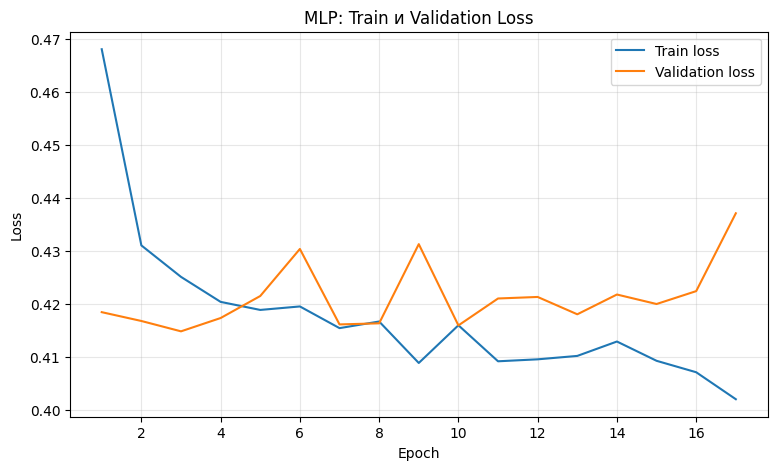

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(history["train_loss"]) + 1),
    history["train_loss"],
    label="Train loss"
)

plt.plot(
    range(1, len(history["val_loss"]) + 1),
    history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP: Train и Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

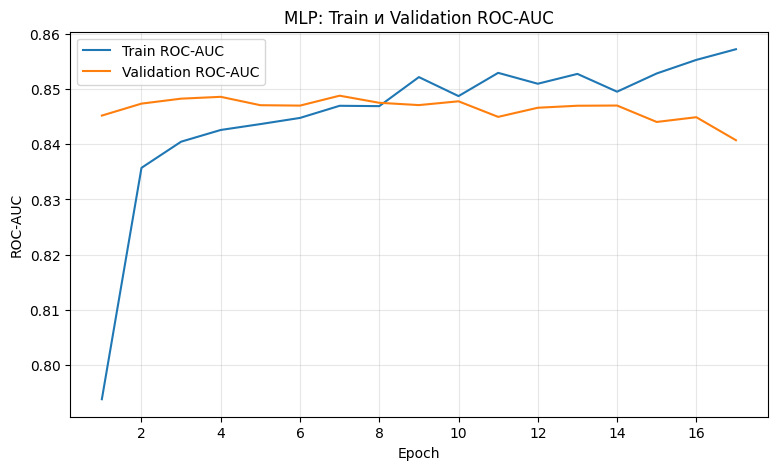

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(history["train_auc"]) + 1),
    history["train_auc"],
    label="Train ROC-AUC"
)

plt.plot(
    range(1, len(history["val_auc"]) + 1),
    history["val_auc"],
    label="Validation ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("MLP: Train и Validation ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

По графикам обучения видно, что после первых эпох качество на обучающей и validation-выборках начинает расходиться.

Train loss продолжает снижаться, а train ROC-AUC — расти. При этом validation loss после первоначального снижения начинает увеличиваться, а validation ROC-AUC выходит на плато и затем снижается.

Это указывает на начало переобучения. Использование Early Stopping позволило остановить обучение до дальнейшего ухудшения качества на validation-выборке и сохранить веса модели с максимальным validation ROC-AUC.


In [ ]:
mlp_model.load_state_dict(best_state)
mlp_model = mlp_model.to(device)

In [ ]:
best_epoch = np.argmax(history["val_auc"]) + 1

print("Лучшая эпоха:", best_epoch)
print("Лучший Validation ROC-AUC:", round(best_val_auc, 4))

Лучшая эпоха: 7
Лучший Validation ROC-AUC: 0.8488


In [ ]:
mlp_model.eval()

mlp_model.eval()

with torch.no_grad():
    val_logits = mlp_model(X_mlp_val_tensor)

    val_probs = torch.sigmoid(
        val_logits
    ).cpu().numpy().ravel()

val_pred = (val_probs >= 0.5).astype(int)

val_true = (
    y_mlp_val_tensor
    .cpu()
    .numpy()
    .ravel()
    .astype(int)
)

mlp_val_metrics = pd.Series({
    "Accuracy": accuracy_score(val_true, val_pred),
    "Precision": precision_score(val_true, val_pred),
    "Recall": recall_score(val_true, val_pred),
    "F1": f1_score(val_true, val_pred),
    "ROC-AUC": roc_auc_score(val_true, val_probs)
})

mlp_val_metrics.round(3)

Accuracy     0.811
Precision    0.703
Recall       0.498
F1           0.583
ROC-AUC      0.849
dtype: float64

### Кросс-валидация MLP

Для корректного сравнения MLP с классическими моделями проводится 5-кратная стратифицированная кросс-валидация.

На каждом фолде предобработка данных обучается только на тренировочной части. Затем создаётся новая нейронная сеть и обучается с использованием Early Stopping по validation ROC-AUC.

Таким образом, MLP оценивается по той же схеме кросс-валидации, что и классические модели.


In [ ]:
mlp_cv_scores = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": []
}

epochs = 200
patience = 10

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):
    print(f"\n========== Fold {fold}/5 ==========")

    # Разделение текущего фолда
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Новый preprocessing для каждого фолда
    fold_preprocessor = clone(preprocessor)

    X_fold_train_processed = fold_preprocessor.fit_transform(
        X_fold_train
    )

    X_fold_val_processed = fold_preprocessor.transform(
        X_fold_val
    )

    # sparse -> dense
    if hasattr(X_fold_train_processed, "toarray"):
        X_fold_train_processed = X_fold_train_processed.toarray()

    if hasattr(X_fold_val_processed, "toarray"):
        X_fold_val_processed = X_fold_val_processed.toarray()

    # Tensor + CUDA
    X_fold_train_tensor = torch.tensor(
        X_fold_train_processed,
        dtype=torch.float32,
        device=device
    )

    y_fold_train_tensor = torch.tensor(
        y_fold_train.values,
        dtype=torch.float32,
        device=device
    ).view(-1, 1)

    X_fold_val_tensor = torch.tensor(
        X_fold_val_processed,
        dtype=torch.float32,
        device=device
    )

    y_fold_val_tensor = torch.tensor(
        y_fold_val.values,
        dtype=torch.float32,
        device=device
    ).view(-1, 1)

    # DataLoader
    fold_dataset = TensorDataset(
        X_fold_train_tensor,
        y_fold_train_tensor
    )

    fold_loader = DataLoader(
        fold_dataset,
        batch_size=64,
        shuffle=True
    )

    # НОВАЯ модель для каждого фолда
    fold_model = ChurnMLP(
        X_fold_train_tensor.shape[1]
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        fold_model.parameters(),
        lr=0.005
    )

    # Early stopping
    best_val_auc = -np.inf
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        # ===== TRAIN =====
        fold_model.train()

        for X_batch, y_batch in fold_loader:
            optimizer.zero_grad()

            logits = fold_model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            loss.backward()
            optimizer.step()

        # ===== VALIDATION =====
        fold_model.eval()

        with torch.no_grad():
            val_logits = fold_model(
                X_fold_val_tensor
            )

            val_probs = torch.sigmoid(
                val_logits
            ).cpu().numpy().ravel()

        val_true = y_fold_val.values

        val_auc = roc_auc_score(
            val_true,
            val_probs
        )

        # ===== EARLY STOPPING =====
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            epochs_without_improvement = 0

            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in fold_model.state_dict().items()
            }

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    # Возвращаем лучшие веса
    fold_model.load_state_dict(best_state)
    fold_model = fold_model.to(device)
    fold_model.eval()

    # Финальная оценка фолда
    with torch.no_grad():
        val_logits = fold_model(
            X_fold_val_tensor
        )

        val_probs = torch.sigmoid(
            val_logits
        ).cpu().numpy().ravel()

    val_pred = (
        val_probs >= 0.5
    ).astype(int)

    mlp_cv_scores["accuracy"].append(
        accuracy_score(val_true, val_pred)
    )

    mlp_cv_scores["precision"].append(
        precision_score(val_true, val_pred)
    )

    mlp_cv_scores["recall"].append(
        recall_score(val_true, val_pred)
    )

    mlp_cv_scores["f1"].append(
        f1_score(val_true, val_pred)
    )

    mlp_cv_scores["roc_auc"].append(
        roc_auc_score(val_true, val_probs)
    )

    print(
        f"Остановлено на эпохе {epoch + 1} | "
        f"ROC-AUC = {mlp_cv_scores['roc_auc'][-1]:.4f}"
    )


========== Fold 1/5 ==========
Остановлено на эпохе 14 | ROC-AUC = 0.8420

========== Fold 2/5 ==========
Остановлено на эпохе 16 | ROC-AUC = 0.8299

========== Fold 3/5 ==========
Остановлено на эпохе 14 | ROC-AUC = 0.8440

========== Fold 4/5 ==========
Остановлено на эпохе 14 | ROC-AUC = 0.8627

========== Fold 5/5 ==========
Остановлено на эпохе 18 | ROC-AUC = 0.8577


In [ ]:
mlp_cv_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        np.mean(mlp_cv_scores["accuracy"]),
        np.mean(mlp_cv_scores["precision"]),
        np.mean(mlp_cv_scores["recall"]),
        np.mean(mlp_cv_scores["f1"]),
        np.mean(mlp_cv_scores["roc_auc"])
    ],
    "Std": [
        np.std(mlp_cv_scores["accuracy"]),
        np.std(mlp_cv_scores["precision"]),
        np.std(mlp_cv_scores["recall"]),
        np.std(mlp_cv_scores["f1"]),
        np.std(mlp_cv_scores["roc_auc"])
    ]
})

mlp_cv_results.round(3)

,Metric,Mean,Std
0,Accuracy,0.804,0.011
1,Precision,0.660,0.027
2,Recall,0.545,0.068
3,F1,0.594,0.039
4,ROC-AUC,0.847,0.012


По результатам 5-кратной кросс-валидации MLP показал средний ROC-AUC `0.847`.

По сравнению с Logistic Regression MLP имеет более высокий Recall (`0.568` против `0.524`), но более низкий Precision (`0.645` против `0.677`).

По F1-score MLP (`0.601`) немного превосходит Logistic Regression (`0.590`), однако уступает Random Forest (`0.638`).

Таким образом, MLP показывает качество, сопоставимое с классическими моделями, но не превосходит их одновременно по всем метрикам.


In [ ]:
final_cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "MLP"
    ],
    "Accuracy": [
        best_logreg_results.loc[0, "Mean"],
        best_rf_results.loc[0, "Mean"],
        catboost_tuned_results.loc[0, "Mean"],
        mlp_cv_results.loc[0, "Mean"]
    ],
    "Precision": [
        best_logreg_results.loc[1, "Mean"],
        best_rf_results.loc[1, "Mean"],
        catboost_tuned_results.loc[1, "Mean"],
        mlp_cv_results.loc[1, "Mean"]
    ],
    "Recall": [
        best_logreg_results.loc[2, "Mean"],
        best_rf_results.loc[2, "Mean"],
        catboost_tuned_results.loc[2, "Mean"],
        mlp_cv_results.loc[2, "Mean"]
    ],
    "F1": [
        best_logreg_results.loc[3, "Mean"],
        best_rf_results.loc[3, "Mean"],
        catboost_tuned_results.loc[3, "Mean"],
        mlp_cv_results.loc[3, "Mean"]
    ],
    "ROC-AUC": [
        best_logreg_results.loc[4, "Mean"],
        best_rf_results.loc[4, "Mean"],
        catboost_tuned_results.loc[4, "Mean"],
        mlp_cv_results.loc[4, "Mean"]
    ]
})

final_cv_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.807,0.677,0.524,0.590,0.848
1,Random Forest,0.774,0.555,0.751,0.638,0.846
2,CatBoost,0.806,0.670,0.530,0.591,0.851
3,MLP,0.804,0.660,0.545,0.594,0.847


## Финальная оценка моделей на тестовой выборке

После выбора архитектур и гиперпараметров по кросс-валидации проведём итоговую оценку моделей на ранее не использовавшейся тестовой выборке.

Все модели обучаются на `X_train`, после чего качество оценивается на `X_test`. На данном этапе гиперпараметры больше не изменяются.


In [ ]:
final_results = []

In [ ]:
start = time.time()

best_logreg.fit(X_train, y_train)

logreg_train_time = time.time() - start

logreg_test_pred = best_logreg.predict(X_test)
logreg_test_proba = best_logreg.predict_proba(X_test)[:, 1]

final_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, logreg_test_pred),
    "Precision": precision_score(y_test, logreg_test_pred),
    "Recall": recall_score(y_test, logreg_test_pred),
    "F1": f1_score(y_test, logreg_test_pred),
    "ROC-AUC": roc_auc_score(y_test, logreg_test_proba),
    "Train time": logreg_train_time
})

In [ ]:
start = time.time()

best_rf.fit(X_train, y_train)

rf_train_time = time.time() - start

rf_test_pred = best_rf.predict(X_test)
rf_test_proba = best_rf.predict_proba(X_test)[:, 1]

final_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_test_pred),
    "Precision": precision_score(y_test, rf_test_pred),
    "Recall": recall_score(y_test, rf_test_pred),
    "F1": f1_score(y_test, rf_test_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_test_proba),
    "Train time": rf_train_time
})

In [ ]:
start = time.time()

best_catboost.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    verbose=False
)

catboost_train_time = time.time() - start

catboost_test_pred = best_catboost.predict(X_test).astype(int)
catboost_test_proba = best_catboost.predict_proba(X_test)[:, 1]

final_results.append({
    "Model": "CatBoost",
    "Accuracy": accuracy_score(y_test, catboost_test_pred),
    "Precision": precision_score(y_test, catboost_test_pred),
    "Recall": recall_score(y_test, catboost_test_pred),
    "F1": f1_score(y_test, catboost_test_pred),
    "ROC-AUC": roc_auc_score(y_test, catboost_test_proba),
    "Train time": catboost_train_time
})

In [ ]:
# ===== MLP: финальная оценка на test =====

X_mlp_test_processed = preprocessor.transform(X_test)

if hasattr(X_mlp_test_processed, "toarray"):
    X_mlp_test_processed = X_mlp_test_processed.toarray()

X_mlp_test_tensor = torch.tensor(
    X_mlp_test_processed,
    dtype=torch.float32,
    device=device
)

mlp_model.eval()

# синхронизация CUDA нужна для корректного замера времени
torch.cuda.synchronize()
start = time.time()

with torch.no_grad():
    test_logits = mlp_model(X_mlp_test_tensor)

    mlp_test_proba = torch.sigmoid(
        test_logits
    ).cpu().numpy().ravel()

torch.cuda.synchronize()
mlp_inference_time = time.time() - start

mlp_test_pred = (mlp_test_proba >= 0.5).astype(int)

mlp_test_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, mlp_test_pred),
    "Precision": precision_score(y_test, mlp_test_pred),
    "Recall": recall_score(y_test, mlp_test_pred),
    "F1": f1_score(y_test, mlp_test_pred),
    "ROC-AUC": roc_auc_score(y_test, mlp_test_proba),
    "Inference time": mlp_inference_time
})

In [ ]:
final_results.append({
    "Model": "MLP",
    "Accuracy": mlp_test_metrics["Accuracy"],
    "Precision": mlp_test_metrics["Precision"],
    "Recall": mlp_test_metrics["Recall"],
    "F1": mlp_test_metrics["F1"],
    "ROC-AUC": mlp_test_metrics["ROC-AUC"],
})

final_results_df = pd.DataFrame(final_results)

final_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train time
0,Logistic Regression,0.803,0.667,0.513,0.580,0.846,0.051
1,Random Forest,0.758,0.531,0.749,0.622,0.844,0.703
2,CatBoost,0.804,0.669,0.519,0.584,0.846,7.486
3,MLP,0.797,0.652,0.505,0.569,0.844,NaN


### Результаты на тестовой выборке

На независимой тестовой выборке модели показали результаты, близкие к полученным при кросс-валидации.

Logistic Regression и CatBoost получили ROC-AUC `0.846`, Random Forest — `0.844`, MLP — `0.844`.

Random Forest сохранил заметно более высокий Recall (`0.749`), то есть при пороге `0.5` обнаруживает большую долю клиентов, которые действительно уходят. При этом его Precision (`0.531`) ниже, чем у остальных моделей.

CatBoost и Logistic Regression показывают более высокий Precision (`0.669` и `0.667` соответственно), но существенно меньший Recall.

MLP получила ROC-AUC `0.844`, что сопоставимо с классическими моделями, однако по итоговым метрикам не показала преимущества над ними.

Таким образом, результаты на тестовой выборке подтверждают выводы, полученные на этапе кросс-валидации.


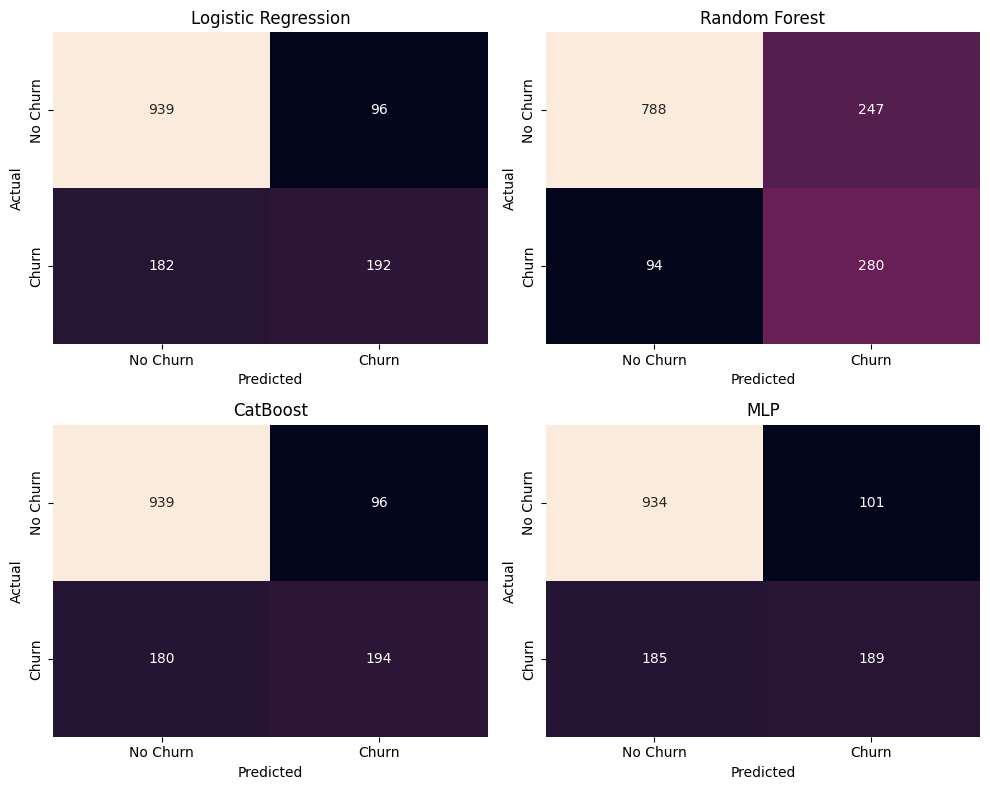

In [ ]:
models_predictions = {
    "Logistic Regression": logreg_test_pred,
    "Random Forest": rf_test_pred,
    "CatBoost": catboost_test_pred,
    "MLP": mlp_test_pred
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (model_name, y_pred) in zip(axes.ravel(), models_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        ax=ax,
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Анализ confusion matrix

Для Logistic Regression и CatBoost результаты практически одинаковы:
- Logistic Regression: `TN = 939`, `FP = 96`, `FN = 182`, `TP = 192`;
- CatBoost: `TN = 939`, `FP = 96`, `FN = 180`, `TP = 194`.

Обе модели достаточно редко ошибочно относят клиента к оттоку, но при этом пропускают почти половину реально ушедших клиентов.

MLP показывает похожую картину:
- `TN = 934`, `FP = 101`, `FN = 185`, `TP = 189`.

Random Forest ведёт себя иначе:
- `TN = 788`, `FP = 247`, `FN = 94`, `TP = 280`.

Random Forest значительно реже пропускает клиентов, которые действительно ушли: количество `FN` снижается до `94` против `180–185` у остальных моделей. Именно поэтому у него существенно выше Recall (`0.749`).

При этом Random Forest чаще ошибочно относит остающихся клиентов к оттоку: `FP = 247` против примерно `96–101` у остальных моделей. Это объясняет его более низкий Precision.

Таким образом, Random Forest сильнее ориентирован на обнаружение потенциального оттока, тогда как Logistic Regression, CatBoost и MLP дают более консервативные предсказания.


### ROC-кривые


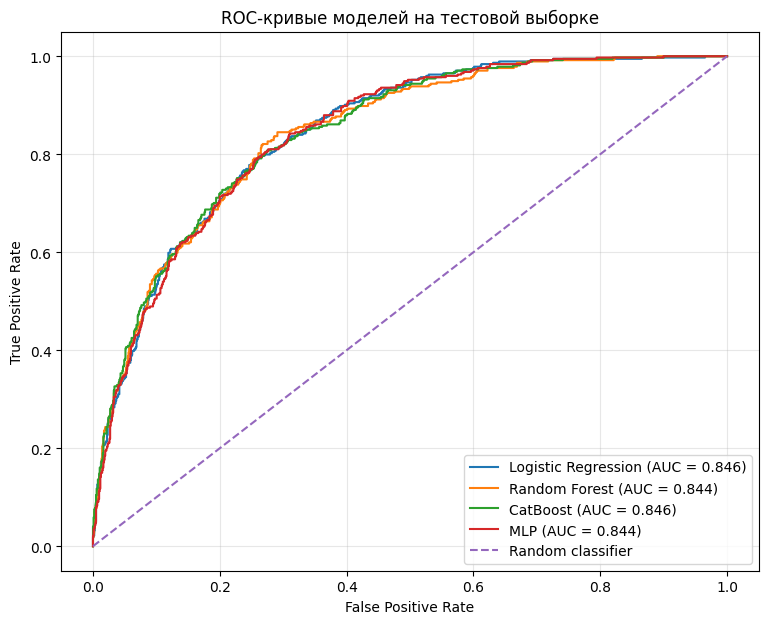

In [ ]:
models_proba = {
    "Logistic Regression": logreg_test_proba,
    "Random Forest": rf_test_proba,
    "CatBoost": catboost_test_proba,
    "MLP": mlp_test_proba
}

plt.figure(figsize=(9, 7))

for model_name, y_proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые моделей на тестовой выборке")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Существенного преимущества одной модели по способности ранжировать клиентов по вероятности оттока на тестовой выборке не наблюдается.


## Анализ порога классификации

Стандартный порог `0.5` не обязательно является оптимальным для задачи прогнозирования оттока.

Для выбора порога используются out-of-fold предсказания на обучающей выборке. Это позволяет исследовать компромисс между Precision и Recall, не используя тестовую выборку при выборе порога.

Анализ проведём для CatBoost и Random Forest, поскольку CatBoost показал максимальный ROC-AUC на кросс-валидации, а Random Forest — максимальный Recall и F1-score.


### Out-of-fold предсказания


In [ ]:
rf_oof_proba = np.zeros(len(X_train))

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]

    fold_rf = clone(best_rf)

    fold_rf.fit(
        X_fold_train,
        y_fold_train
    )

    rf_oof_proba[val_idx] = fold_rf.predict_proba(
        X_fold_val
    )[:, 1]

    print(f"RF fold {fold}/5 готов")

RF fold 1/5 готов
RF fold 2/5 готов
RF fold 3/5 готов
RF fold 4/5 готов
RF fold 5/5 готов


In [ ]:
catboost_oof_proba = np.zeros(len(X_train))

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]

    fold_catboost = CatBoostClassifier(
        **best_catboost.get_params()
    )

    fold_catboost.fit(
        X_fold_train,
        y_fold_train,
        cat_features=cat_features,
        verbose=False
    )

    catboost_oof_proba[val_idx] = fold_catboost.predict_proba(
        X_fold_val
    )[:, 1]

    print(f"CatBoost fold {fold}/5 готов")

CatBoost fold 1/5 готов
CatBoost fold 2/5 готов
CatBoost fold 3/5 готов
CatBoost fold 4/5 готов
CatBoost fold 5/5 готов


In [ ]:
print(
    "Random Forest OOF ROC-AUC:",
    round(roc_auc_score(y_train, rf_oof_proba), 4)
)

print(
    "CatBoost OOF ROC-AUC:",
    round(roc_auc_score(y_train, catboost_oof_proba), 4)
)

Random Forest OOF ROC-AUC: 0.8455
CatBoost OOF ROC-AUC: 0.85


### Поиск порога по F1-score


In [ ]:
thresholds = np.arange(
    0.10,
    0.81,
    0.01
)

threshold_results = []

for model_name, proba in {
    "Random Forest": rf_oof_proba,
    "CatBoost": catboost_oof_proba
}.items():

    for threshold in thresholds:

        pred = (
            proba >= threshold
        ).astype(int)

        threshold_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision_score(
                y_train,
                pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_train,
                pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_train,
                pred,
                zero_division=0
            )
        })

threshold_df = pd.DataFrame(
    threshold_results
)

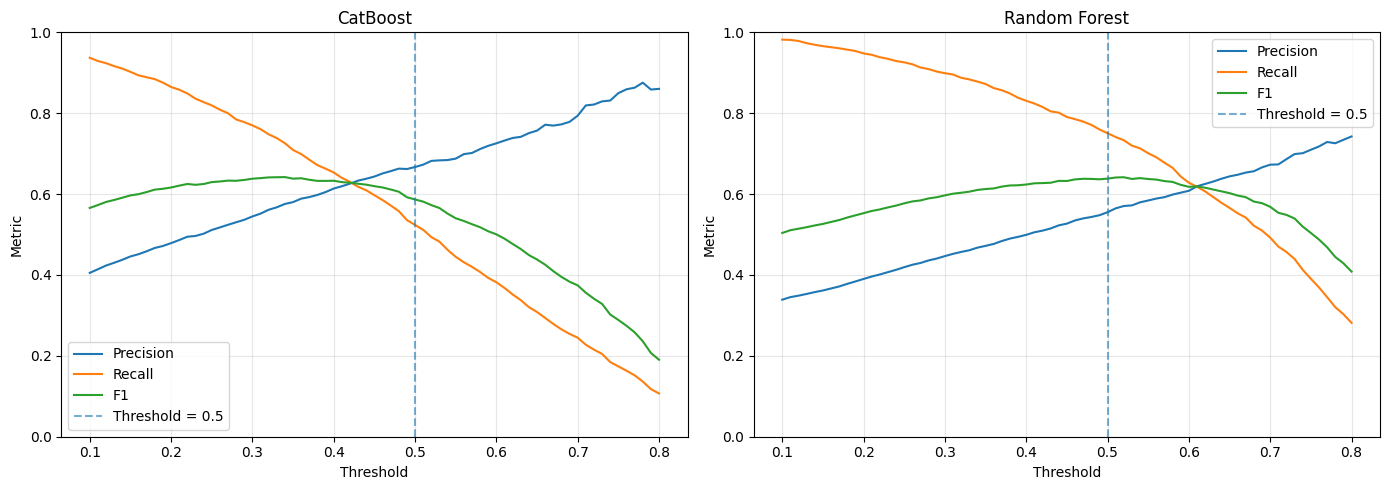

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for ax, model_name in zip(
    axes,
    ["CatBoost", "Random Forest"]
):
    model_df = threshold_df[
        threshold_df["Model"] == model_name
    ]

    ax.plot(
        model_df["Threshold"],
        model_df["Precision"],
        label="Precision"
    )

    ax.plot(
        model_df["Threshold"],
        model_df["Recall"],
        label="Recall"
    )

    ax.plot(
        model_df["Threshold"],
        model_df["F1"],
        label="F1"
    )

    ax.axvline(
        0.5,
        linestyle="--",
        alpha=0.6,
        label="Threshold = 0.5"
    )

    ax.set_title(model_name)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
for model_name in [
    "CatBoost",
    "Random Forest"
]:
    model_df = threshold_df[
        threshold_df["Model"] == model_name
    ]

    best_row = model_df.loc[
        model_df["F1"].idxmax()
    ]

    print(
        f"{model_name}: "
        f"threshold={best_row['Threshold']:.2f}, "
        f"precision={best_row['Precision']:.3f}, "
        f"recall={best_row['Recall']:.3f}, "
        f"f1={best_row['F1']:.3f}"
    )

CatBoost: threshold=0.34, precision=0.576, recall=0.726, f1=0.642
Random Forest: threshold=0.52, precision=0.571, recall=0.733, f1=0.642


Анализ out-of-fold предсказаний показал, что стандартный порог `0.5` не является оптимальным для CatBoost по F1-score.

Для CatBoost максимальный F1-score достигается при пороге `0.34`:

- Precision = `0.576`;
- Recall = `0.726`;
- F1 = `0.642`.

Для Random Forest оптимальный порог практически не отличается от стандартного и составляет `0.52`:

- Precision = `0.571`;
- Recall = `0.733`;
- F1 = `0.642`.

Таким образом, после настройки порога CatBoost и Random Forest показывают практически одинаковый баланс Precision и Recall. При этом CatBoost сохраняет небольшое преимущество по ROC-AUC на кросс-валидации.


### Проверка зафиксированных порогов на тестовой выборке


In [ ]:
catboost_test_pred_tuned = (
    catboost_test_proba >= 0.34
).astype(int)

rf_test_pred_tuned = (
    rf_test_proba >= 0.52
).astype(int)

threshold_test_results = pd.DataFrame([
    {
        "Model": "CatBoost",
        "Threshold": 0.34,
        "Accuracy": accuracy_score(y_test, catboost_test_pred_tuned),
        "Precision": precision_score(y_test, catboost_test_pred_tuned),
        "Recall": recall_score(y_test, catboost_test_pred_tuned),
        "F1": f1_score(y_test, catboost_test_pred_tuned),
        "ROC-AUC": roc_auc_score(y_test, catboost_test_proba)
    },
    {
        "Model": "Random Forest",
        "Threshold": 0.52,
        "Accuracy": accuracy_score(y_test, rf_test_pred_tuned),
        "Precision": precision_score(y_test, rf_test_pred_tuned),
        "Recall": recall_score(y_test, rf_test_pred_tuned),
        "F1": f1_score(y_test, rf_test_pred_tuned),
        "ROC-AUC": roc_auc_score(y_test, rf_test_proba)
    }
])

threshold_test_results.round(3)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,CatBoost,0.34,0.777,0.562,0.727,0.634,0.846
1,Random Forest,0.52,0.767,0.545,0.738,0.627,0.844


Пороги классификации были выбраны по out-of-fold предсказаниям на обучающей выборке и затем без дополнительной настройки применены к тестовой выборке.

Для CatBoost при пороге `0.34` получены:

- Accuracy = `0.777`;
- Precision = `0.562`;
- Recall = `0.727`;
- F1 = `0.634`;
- ROC-AUC = `0.846`.

Для Random Forest при пороге `0.52`:

- Accuracy = `0.767`;
- Precision = `0.545`;
- Recall = `0.738`;
- F1 = `0.627`;
- ROC-AUC = `0.844`.

Random Forest сохраняет немного более высокий Recall, однако CatBoost показывает более высокий Precision, F1-score и ROC-AUC.

По совокупности результатов в качестве основной модели выбирается CatBoost с порогом классификации `0.34`.


## SHAP-анализ CatBoost

Для интерпретации выбранной модели CatBoost используются SHAP-значения. Они позволяют оценить вклад каждого признака в прогноз модели и определить признаки, оказывающие наибольшее влияние на предсказание оттока.

In [ ]:
test_pool = Pool(
    X_test,
    y_test,
    cat_features=cat_features
)

catboost_shap_values = best_catboost.get_feature_importance(
    test_pool,
    type="ShapValues"
)

catboost_shap_values = catboost_shap_values[:, :-1]

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_ABS_SHAP": np.abs(catboost_shap_values).mean(axis=0)
}).sort_values(
    "Mean_ABS_SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean_ABS_SHAP
14,Contract,0.627382
17,MonthlyCharges,0.430244
4,tenure,0.427521
11,TechSupport,0.248005
8,OnlineSecurity,0.244304
7,InternetService,0.197197
16,PaymentMethod,0.173041
18,TotalCharges,0.159622
15,PaperlessBilling,0.138317
6,MultipleLines,0.091091


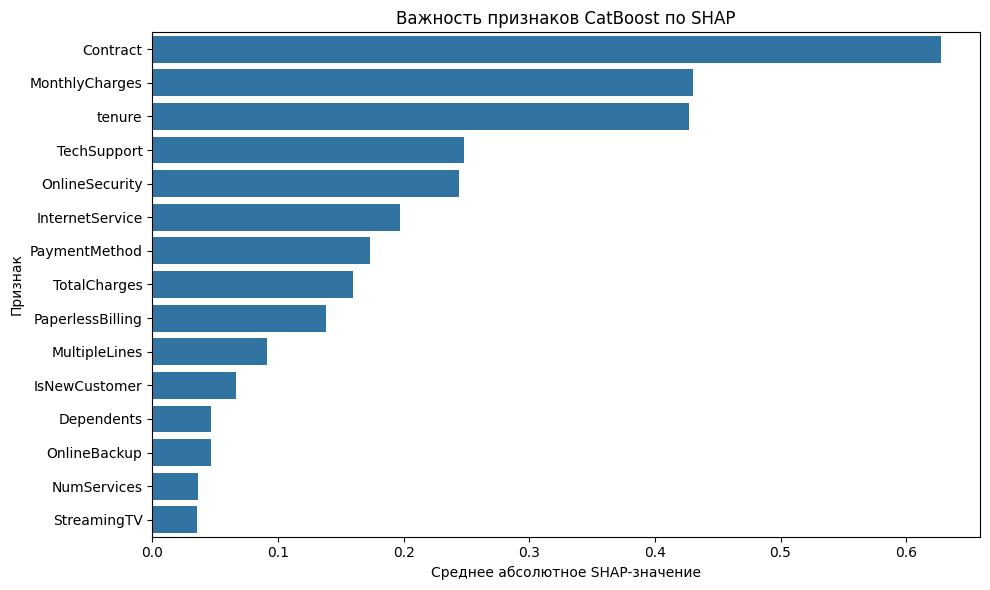

In [204]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=shap_importance.head(15),
    x="Mean_ABS_SHAP",
    y="Feature"
)

plt.title("Важность признаков CatBoost по SHAP")
plt.xlabel("Среднее абсолютное SHAP-значение")
plt.ylabel("Признак")

plt.tight_layout()
plt.show()

### Вывод по SHAP-анализу

Полученные результаты согласуются с выводами EDA: именно для типа контракта, срока обслуживания и ежемесячных платежей ранее наблюдались заметные различия между ушедшими и оставшимися клиентами.

При этом данный график отражает только величину влияния признаков на прогноз модели и не показывает, увеличивает или уменьшает конкретное значение признака вероятность оттока.

## Бизнес-интерпретация модели

Для практического применения модели важно учитывать не только качество классификации, но и экономический эффект.

В качестве основной модели используется CatBoost с порогом `0.34`, выбранным по out-of-fold предсказаниям.

Модель позволяет выделить клиентов с повышенным риском оттока и направить им предложение на удержание.

Поскольку датасет не содержит фактической стоимости retention-кампании и эффективности таких предложений, далее проводится сценарный анализ при различных бизнес-параметрах.


### Параметры retention-кампании


In [ ]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    catboost_test_pred_tuned
).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)
print("Клиентов для retention-кампании:", tp + fp)

TN: 823
FP: 212
FN: 102
TP: 272
Клиентов для retention-кампании: 484


### Сценарный анализ ROI


In [ ]:
def calculate_business_metrics(
    tp,
    fp,
    fn,
    retention_cost,
    lost_customer_value,
    retention_success_rate
):
    targeted_customers = tp + fp

    # сколько churn-клиентов реально удастся удержать
    retained_customers = tp * retention_success_rate

    # стоимость всей retention-кампании
    campaign_cost = targeted_customers * retention_cost

    # предотвращённые потери
    saved_value = retained_customers * lost_customer_value

    # чистый экономический эффект
    net_profit = saved_value - campaign_cost

    # ROI кампании
    roi = (
        net_profit / campaign_cost
        if campaign_cost > 0
        else 0
    )

    return {
        "Targeted": targeted_customers,
        "Retained": retained_customers,
        "Campaign cost": campaign_cost,
        "Saved value": saved_value,
        "Net profit": net_profit,
        "ROI": roi
    }

In [ ]:
business_results = []

for retention_cost in [25, 50, 100]:
    for lost_customer_value in [300, 600, 1200]:
        for retention_success_rate in [0.1, 0.2, 0.3]:

            result = calculate_business_metrics(
                tp=tp,
                fp=fp,
                fn=fn,
                retention_cost=retention_cost,
                lost_customer_value=lost_customer_value,
                retention_success_rate=retention_success_rate
            )

            business_results.append({
                "Стоимость удержания": retention_cost,
                "Потери от ухода клиента": lost_customer_value,
                "Вероятность удержания": retention_success_rate,
                **result
            })

business_df = pd.DataFrame(business_results)

business_df.head()

,Стоимость удержания,Потери от ухода клиента,Вероятность удержания,Targeted,Retained,Campaign cost,Saved value,Net profit,ROI
0,25,300,0.1,484,27.2,12100,8160.0,-3940.0,-0.325620
1,25,300,0.2,484,54.4,12100,16320.0,4220.0,0.348760
2,25,300,0.3,484,81.6,12100,24480.0,12380.0,1.023140
3,25,600,0.1,484,27.2,12100,16320.0,4220.0,0.348760
4,25,600,0.2,484,54.4,12100,32640.0,20540.0,1.697521


In [ ]:
roi_table = (
    business_df[
        business_df["Стоимость удержания"] == 50
    ]
    .pivot(
        index="Вероятность удержания",
        columns="Потери от ухода клиента",
        values="ROI"
    )
)

roi_table.round(2)

Потери от ухода клиента,300,600,1200
Вероятность удержания,,,
0.1,-0.66,-0.33,0.35
0.2,-0.33,0.35,1.70
0.3,0.01,1.02,3.05


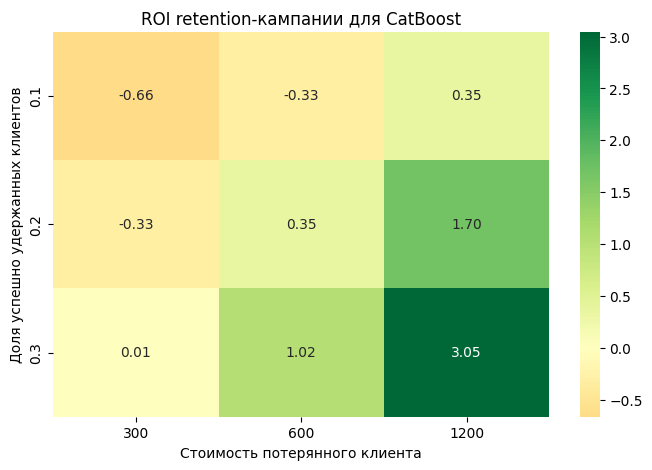

In [195]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    roi_table,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0
)

plt.title("ROI retention-кампании для CatBoost")
plt.xlabel("Стоимость потерянного клиента")
plt.ylabel("Доля успешно удержанных клиентов")

plt.show()


Экономический эффект модели существенно зависит от трёх факторов:

- стоимости предложения на удержание;
- стоимости потери клиента;
- доли клиентов, которых удаётся успешно удержать.

При стоимости retention-предложения `$50`:

- если стоимость потерянного клиента составляет `$300`, кампания убыточна при эффективности удержания `10–20%` и практически выходит в ноль при `30%`;
- при стоимости потерянного клиента `$600` положительный ROI появляется уже при эффективности удержания `20%`;
- при стоимости потерянного клиента `$1200` кампания показывает положительный ROI даже при эффективности удержания `10%`.

Максимальный ROI в рассмотренных сценариях достигается при стоимости потерянного клиента `$1200` и эффективности удержания `30%` и составляет `3.05`, то есть чистый эффект примерно в 3.05 раза превышает затраты на кампанию.

Таким образом, применение модели экономически оправдано не при любых условиях: результат зависит от ценности клиента и фактической эффективности retention-механики. Модель позволяет сузить аудиторию кампании до клиентов с повышенным риском оттока, однако окончательное решение о запуске retention-кампании должно учитывать её реальные бизнес-параметры.


## Итоговые выводы

В работе была решена задача бинарной классификации оттока клиентов телеком-компании.

На этапе EDA были выявлены несколько признаков, наиболее заметно связанных с оттоком. Клиенты с меньшим `tenure` значительно чаще уходят, а вероятность оттока последовательно снижается по мере увеличения срока обслуживания. Также более высокий churn наблюдается у клиентов с помесячным контрактом, оплатой через `Electronic check`, использованием `Fiber optic` и отсутствием некоторых дополнительных услуг, в частности `OnlineSecurity` и `TechSupport`.

Для обучения моделей была построена единая схема предобработки данных. Числовые признаки масштабировались, категориальные кодировались с помощью One-Hot Encoding. Дополнительно были созданы признаки `NumServices`, `IsNewCustomer` и `AutoPayment`.

В качестве классических моделей были рассмотрены Logistic Regression, Random Forest и CatBoost. Для каждой модели проводился подбор гиперпараметров и 5-кратная стратифицированная кросс-валидация.

По результатам кросс-валидации:

- Logistic Regression: ROC-AUC = `0.848`;
- Random Forest: ROC-AUC = `0.846`;
- CatBoost: ROC-AUC = `0.851`;
- MLP: ROC-AUC = `0.847`.

CatBoost показал максимальный ROC-AUC, тогда как Random Forest при стандартном пороге `0.5` показал наибольший Recall и F1-score.

Для нейросетевой модели была использована MLP с двумя скрытыми слоями `64 → 32`, функцией активации ReLU и Dropout `0.3` и `0.2`. Обучение проводилось с использованием `BCEWithLogitsLoss`, оптимизатора Adam и Early Stopping. Анализ кривых обучения показал, что после первых эпох качество на обучающей выборке продолжало расти, тогда как validation ROC-AUC переставал улучшаться, поэтому Early Stopping позволил сохранить состояние модели с лучшим качеством на validation.

MLP получила средний ROC-AUC `0.847` по 5-fold CV и не показала преимущества над классическими моделями на данном датасете.

На независимой тестовой выборке значения ROC-AUC также оказались близкими:

- Logistic Regression — `0.846`;
- Random Forest — `0.844`;
- CatBoost — `0.846`;
- MLP — `0.844`.

Confusion matrix показала различия в поведении моделей при пороге `0.5`. Random Forest обнаруживает значительно большую долю реально уходящих клиентов, но при этом создаёт больше ложноположительных срабатываний. Logistic Regression, CatBoost и MLP делают более консервативные предсказания и имеют более высокий Precision, но пропускают больше churn-клиентов.

Дополнительно был проведён анализ порога классификации на out-of-fold предсказаниях обучающей выборки. Для CatBoost максимальный F1-score был достигнут при пороге `0.34`, а для Random Forest — при пороге `0.52`.

После применения заранее выбранных порогов к тестовой выборке:

- CatBoost: Precision = `0.562`, Recall = `0.727`, F1 = `0.634`, ROC-AUC = `0.846`;
- Random Forest: Precision = `0.545`, Recall = `0.738`, F1 = `0.627`, ROC-AUC = `0.844`.

В качестве основной модели был выбран CatBoost с порогом `0.34`: он показал лучший ROC-AUC на кросс-валидации и после настройки порога сохранил высокий Recall при более высоких Precision и F1-score по сравнению с Random Forest на тестовой выборке.

Бизнес-анализ показал, что экономический эффект retention-кампании зависит от стоимости удержания, стоимости потери клиента и эффективности самого предложения. Например, при стоимости retention-предложения `$50` и стоимости потерянного клиента `$1200` кампания имеет положительный ROI даже при успешном удержании только `10%` выявленных churn-клиентов. При более низкой ценности клиента для положительного эффекта требуется более высокая эффективность retention-механики.

Таким образом, модель может использоваться для ранжирования клиентов по риску оттока и формирования целевой аудитории retention-кампаний. При этом решение о конкретном пороге классификации и запуске кампании должно приниматься с учётом реальной стоимости контакта с клиентом и эффективности используемых способов удержания.
